# Zero-Shot Classification of Crisis-Related News for Forecasting Flight Cancellations

**Team Members:** Rishiv Bawa, Gaurav Sharma, Veekshith Sumanth  
**Research Question:** Can zero-shot classification applied to global crisis-related news headlines predict U.S. flight cancellations?  
**Hypothesis:** Crisis event signals from zero-shot classification exhibit statistically significant temporal correlation (r >= 0.15, p < 0.05) with U.S. flight cancellation rates at lag windows of 0-3 days, enabling early warning identification.

## Pipeline Overview
- **Stage 1:** Raw Data (global GDELT crisis events + U.S. flight cancellation records)
- **Stage 2:** Filtered & Classified (zero-shot disruption labels, temporal aggregation, community detection)
- **Stage 3:** Actionable Intelligence (correlation analysis, predictive patterns, lead-time forecasting)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## STAGE 1: RAW DATA COLLECTION
### 3.1 Data Collection (Methodology)

In [ ]:
# =========================
# Install Required Libraries
# =========================
# Check CUDA availability
!nvcc --version

print("\nGPU detected")

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

GPU detected


In [2]:

!pip install -q matplotlib seaborn scikit-learn networkx python-louvain

print("All additional packages installed for crisis analysis pipeline")

All additional packages installed for crisis analysis pipeline


In [3]:

!pip install -q matplotlib seaborn scikit-learn networkx python-louvain

print("All additional packages installed for crisis analysis pipeline")

All additional packages installed for crisis analysis pipeline


In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully")
print(f"Random seed set to: {RANDOM_SEED}")

Libraries imported successfully
Random seed set to: 42


In [5]:
import os

# Define paths for Google Drive storage
DRIVE_PATH = '/content/drive/MyDrive/OSINT_files/'
MODEL_FILENAME = 'Mistral-Nemo-Instruct-2407-Q5_K_M.gguf'
MODEL_LOCAL_PATH = MODEL_FILENAME
MODEL_DRIVE_PATH = os.path.join(DRIVE_PATH, MODEL_FILENAME)

# Ensure the OSINT_files directory exists in Google Drive
if not os.path.exists(DRIVE_PATH):
    os.makedirs(DRIVE_PATH, exist_ok=True)
    print(f"Created directory: {DRIVE_PATH}")

print("Checking for Mistral-Nemo model...")
print(f"Model will be stored in: {MODEL_DRIVE_PATH}")

# Check if model is already in Google Drive
if os.path.exists(MODEL_DRIVE_PATH):
    print(f"Model '{MODEL_FILENAME}' found in Google Drive. Skipping download.")
# Check if model is in the local Colab session
elif os.path.exists(MODEL_LOCAL_PATH):
    print(f"Model '{MODEL_FILENAME}' found locally. Copying to Google Drive for persistent storage...")
    !cp {MODEL_LOCAL_PATH} {MODEL_DRIVE_PATH}
    !rm {MODEL_LOCAL_PATH}
    print(f"Model copied to Google Drive and local file removed.")
# Download the model if not found anywhere
else:
    print(f"Model '{MODEL_FILENAME}' not found. Downloading (~8GB, may take 5-10 minutes)...")
    !wget https://huggingface.co/bartowski/Mistral-Nemo-Instruct-2407-GGUF/resolve/main/{MODEL_FILENAME}

    if os.path.exists(MODEL_LOCAL_PATH):
        print(f"Download complete. Copying '{MODEL_FILENAME}' to Google Drive...")
        !cp {MODEL_LOCAL_PATH} {MODEL_DRIVE_PATH}
        !rm {MODEL_LOCAL_PATH}
        print(f"Model copied to Google Drive. You won't need to download again!")
    else:
        print(f"ERROR: Download of {MODEL_FILENAME} failed.")

print("\nModel setup complete. Model will persist in Google Drive across sessions.")

Checking for Mistral-Nemo model...
Model will be stored in: /content/drive/MyDrive/OSINT_files/Mistral-Nemo-Instruct-2407-Q5_K_M.gguf
Model 'Mistral-Nemo-Instruct-2407-Q5_K_M.gguf' found in Google Drive. Skipping download.

Model setup complete. Model will persist in Google Drive across sessions.


### Data Source 1: GDELT Crisis Events

**Methodology (3.1):**
- **Source:** GDELT Events 2.0 database (https://www.gdeltproject.org/)
- **File:** `gdelt_crisis_aviation_clean.csv` (pre-filtered dataset)
- **Time Period:** January 2024 - December 2024
- **Records:** 10,122 aviation-related crisis events
- **File Size:** ~5MB (optimized for Google Colab upload)
- **Selection Criteria:** Events filtered by CAMEO crisis codes (14=Protest, 17=Coerce, 18=Assault, 19=Fight, 20=Mass Violence) AND aviation-related keywords
- **Pre-filtering:** Dataset was pre-filtered from ~30 million global GDELT events to only aviation-related crisis events
- **Justification:** GDELT provides structured, timestamped event data from global news sources, enabling temporal correlation analysis. Using pre-filtered data eliminates need for large file processing in Google Colab.

In [6]:
import pandas as pd

# Load pre-filtered GDELT crisis-aviation events
# File: gdelt_crisis_aviation_clean.csv (~5MB, 10,122 aviation crisis events from 2024)

print("Loading pre-filtered GDELT crisis events...")
print("File: gdelt_crisis_aviation_clean.csv")
print("Note: This file contains only aviation-related crisis events from 2024")
print("Benefit: Ready-to-use dataset for Google Colab (no additional filtering needed)\n")

# Define the path to your files in Google Drive
DRIVE_PATH = '/content/drive/MyDrive/OSINT_files/'
CRISIS_FILE = DRIVE_PATH + 'gdelt_crisis_aviation_clean.csv'

try:
    df_crisis = pd.read_csv(CRISIS_FILE)

    # Ensure data is filtered to 2024 only
    df_crisis['Day'] = df_crisis['Day'].astype(str)
    df_crisis = df_crisis[df_crisis['Day'].str.startswith('2024')].copy()

    print(f"\u2713 Crisis events loaded successfully")
    print(f"\nDataset Summary:")
    print(f"  Total records: {len(df_crisis):,}")
    print(f"  Date range: {df_crisis['Day'].min()} to {df_crisis['Day'].max()}")
    print(f"  Columns: {df_crisis.columns.tolist()[:10]}...")

    print(f"\nEvent Root Code Distribution:")
    print(df_crisis['EventRootCode'].value_counts())

    print(f"\n{'='*80}")
    print(f"SUCCESS: Loaded {len(df_crisis):,} aviation crisis events (2024)")
    print(f"{'='*80}")

except FileNotFoundError:
    print(f"ERROR: {CRISIS_FILE} not found")
    print("\nPlease ensure 'gdelt_crisis_aviation_clean.csv' is uploaded to your Google Drive in the 'OSINT_files' folder, and that your drive is mounted.")
    df_crisis = None
except Exception as e:
    print(f"ERROR loading crisis data: {e}")
    df_crisis = None

Loading pre-filtered GDELT crisis events...
File: gdelt_crisis_aviation_clean.csv
Note: This file contains only aviation-related crisis events from 2024
Benefit: Ready-to-use dataset for Google Colab (no additional filtering needed)

✓ Crisis events loaded successfully

Dataset Summary:
  Total records: 10,122
  Date range: 20240101 to 20241002
  Columns: ['GlobalEventID', 'Day', 'MonthYear', 'Year', 'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode', 'Actor1EthnicCode']...

Event Root Code Distribution:
EventRootCode
19    5718
17    2736
18    1028
14     560
20      80
Name: count, dtype: int64

SUCCESS: Loaded 10,122 aviation crisis events (2024)


### Data Source 2: Flight Cancellation Records

**Methodology (3.1 continued):**
- **Primary Source:** U.S. Department of Transportation (DOT), Bureau of Transportation Statistics (BTS)
- **Database:** Marketing Carrier On-Time Performance (T-100 Segment)
- **Access Repository:** Kaggle, "Flight Delay Dataset - 2024" by H. Patil
- **URL:** https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024
- **Legal Status:** Public Domain (U.S. Government Work, 17 U.S.C. § 105)
- **Working File:** `flight_cancellations_daily_2024.csv` (pre-aggregated analysis file)
- **Time Period:** January 2024 - December 2024 (Full Year)
- **Records:** 366 daily aggregated records (not raw flight-level data)
- **Variables:** date, total_flights, cancelled_flights, cancellation_rate, is_spike (5 variables)
- **Data Characteristics:** Daily aggregated flight statistics covering entire 2024
- **Temporal Coverage:** 366 days (2024 is a leap year)
- **File Size:** ~20KB (vs 1.2GB raw data) - optimized for Google Colab
- **Original Data:** Aggregated from 7,079,081 raw flight records
- **Justification:** Using pre-aggregated daily statistics enables easy upload to Google Colab without sacrificing analytical capability. All necessary metrics (cancellation rates, spike detection) are preserved in the daily aggregation.

In [7]:
import pandas as pd

# Load PRE-AGGREGATED flight cancellation data (for Google Colab)
# File: flight_cancellations_daily_2024.csv (366 days, already aggregated)
# Note: Using pre-aggregated data to avoid uploading 1.2GB file to Colab

print("Loading pre-aggregated flight cancellation data...")
print("File: flight_cancellations_daily_2024.csv (FULL YEAR 2024)")
print("Note: This file is already aggregated to daily level (366 rows vs 7M+ raw rows)")
print("Benefit: Faster upload to Google Colab (~20KB vs 1.2GB)\n")

# Define the path to your files in Google Drive
DRIVE_PATH = '/content/drive/MyDrive/OSINT_files/'
FLIGHTS_FILE = DRIVE_PATH + 'flight_cancellations_daily_2024.csv'

try:
    # Load the pre-aggregated daily flight data
    df_flights_daily = pd.read_csv(FLIGHTS_FILE)

    # Convert date column to datetime
    df_flights_daily['date'] = pd.to_datetime(df_flights_daily['date'])

    print(f"\u2713 Pre-aggregated data loaded successfully")
    print(f"\nDataset Summary:")
    print(f"  Total days: {len(df_flights_daily)}")
    print(f"  Date range: {df_flights_daily['date'].min().date()} to {df_flights_daily['date'].max().date()}")
    print(f"  Columns: {list(df_flights_daily.columns)}")

    # Verify all expected columns exist
    required_cols = ['date', 'total_flights', 'cancelled_flights', 'cancellation_rate', 'is_spike']
    if all(col in df_flights_daily.columns for col in required_cols):
        print(f"  \u2713 All required columns present")

    # Display statistics
    print(f"\nFlight Cancellation Statistics:")
    print(f"  Mean cancellation rate: {df_flights_daily['cancellation_rate'].mean():.4f}")
    print(f"  Std dev: {df_flights_daily['cancellation_rate'].std():.4f}")
    print(f"  Days with cancellation spikes: {df_flights_daily['is_spike'].sum()}")
    print(f"  Total flights (sum): {df_flights_daily['total_flights'].sum():,}")
    print(f"  Total cancelled (sum): {df_flights_daily['cancelled_flights'].sum():,}")

    # Verify full year coverage
    print(f"\nMonth distribution:")
    month_dist = df_flights_daily['date'].dt.month.value_counts().sort_index()
    print(month_dist)
    print(f"\u2713 All 12 months verified: {len(month_dist) == 12}")

    print(f"\nSample daily statistics:")
    print(df_flights_daily.head(10))

    print(f"\n{'='*80}")
    print("SUCCESS: Full year 2024 pre-aggregated flight data loaded (366 days)")
    print(f"{'='*80}")

except FileNotFoundError:
    print(f"ERROR: {FLIGHTS_FILE} not found")
    print("\nPlease ensure 'flight_cancellations_daily_2024.csv' is uploaded to your Google Drive in the 'OSINT_files' folder, and that your drive is mounted.")
    df_flights_daily = None
except Exception as e:
    print(f"ERROR loading flight data: {e}")
    df_flights_daily = None

Loading pre-aggregated flight cancellation data...
File: flight_cancellations_daily_2024.csv (FULL YEAR 2024)
Note: This file is already aggregated to daily level (366 rows vs 7M+ raw rows)
Benefit: Faster upload to Google Colab (~20KB vs 1.2GB)

✓ Pre-aggregated data loaded successfully

Dataset Summary:
  Total days: 366
  Date range: 2024-01-01 to 2024-12-31
  Columns: ['date', 'cancelled_flights', 'total_flights', 'cancellation_rate', 'is_spike']
  ✓ All required columns present

Flight Cancellation Statistics:
  Mean cancellation rate: 0.0135
  Std dev: 0.0229
  Days with cancellation spikes: 9
  Total flights (sum): 7,079,081
  Total cancelled (sum): 96,315

Month distribution:
date
1     31
2     29
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    31
Name: count, dtype: int64
✓ All 12 months verified: True

Sample daily statistics:
        date  cancelled_flights  total_flights  cancellation_rate  is_spike
0 2024-01-01                 18    

---
## STAGE 1 COMPLETE

**Summary:**
- GDELT crisis events loaded from `gdelt_crisis_aviation_clean.csv` (global crisis signals filtered to aviation relevance)
- U.S. flight cancellation data loaded from `flight_cancellations_daily_2024.csv` (pre-aggregated daily format)
- Both datasets are ready for temporal alignment

**Data Files:**
1. `Crisis_Flight_Cancellation_Pipeline_8.ipynb` - Analysis notebook
2. `gdelt_crisis_aviation_clean.csv` - Pre-filtered crisis events (~5MB, 10,122 records loaded)
3. `flight_cancellations_daily_2024.csv` - Pre-aggregated daily stats (~20KB, 366 days)

**Data Coverage Clarification (Why crisis appears to end in October):**
- Crisis events available in the current classified working set: January - October 2024
- Flight data coverage: January - December 2024 (366 days, full year)
- Stage 3 dataset still spans all 366 days; for days without crisis events, crisis feature counts are filled with 0
- Interpretation: We model delayed impact of available global crisis signals on full-year U.S. cancellation outcomes

**Data Optimization:**
- Using `flight_cancellations_daily_2024.csv` (366 rows, ~20KB) instead of raw flight data (7M+ rows, 1.2GB)
- Using `gdelt_crisis_aviation_clean.csv` (pre-filtered) instead of raw GDELT (30M+ rows, multi-GB)
- Total data size: ~5.02MB (notebook + 2 CSV files)
- Datasets are analysis-ready, eliminating preprocessing overhead

**Event Distribution (Crisis Events - Loaded):**
- Fight (19): 5,718 events
- Coerce (17): 2,736 events
- Assault (18): 1,028 events
- Protest (14): 560 events
- Mass Violence (20): 80 events

**Flight Data Statistics:**
- Total flights (full year aggregated): 7,079,081 flights
- Total cancelled (full year): 96,315 flights
- Days with cancellation spikes: 9 days (>90th percentile)
- Mean cancellation rate: 1.35%
- All 12 months verified with data (366 days - leap year)

Both datasets are now ready for Stage 2 preprocessing and classification.

---
## STAGE 2: DATA PREPROCESSING & CLASSIFICATION
### 3.2 Data Preprocessing (Methodology)

### Preprocessing Steps (Stage 1 → Stage 2 Transition)

**Methodology (3.2):**

**Crisis Events Preprocessing:**
1. **Timestamp Normalization:** Convert GDELT Day format (YYYYMMDD) to datetime objects
2. **Text Construction:** Create `event_text` from structured fields (Actor1, Actor2, Location, EventCode)
3. **Text Validity Filter:** Remove events with text <10 characters (minimal filtering, 0 events removed)
4. **Deduplication:** Remove events with identical (Day, EventRootCode, Actors, Location) - 1,581 duplicates removed
5. **Temporal Filtering:** Ensure all events fall within 2024

**Flight Data Preprocessing:**
1. **Date Alignment:** Ensure datetime format matches crisis events  
2. **Already Aggregated:** Pre-aggregated to daily level in Stage 1 (366 days)
3. **Spike Detection:** Days with >90th percentile cancellation rates flagged (9 spike days identified)

**Noise Reduction Summary:**
- Crisis events: 10,122 loaded → 8,541 after preprocessing (15.6% duplicates removed)
- Flight records: All 366 daily records valid (pre-aggregated, ready for analysis)
- Final preprocessed dataset: 8,541 unique crisis events ready for classification
- Flight records: All records valid (already aggregated to daily level)

In [ ]:
# =========================
# Preprocess Crisis Events
# =========================

if df_crisis is not None:
    print(f"Starting preprocessing with {len(df_crisis):,} crisis events")

    # Convert Day to datetime
    print(f"\nStep 1: Timestamp Normalization")
    df_crisis['Day'] = df_crisis['Day'].astype(str)
    df_crisis['date'] = pd.to_datetime(df_crisis['Day'], format='%Y%m%d', errors='coerce')

    # Filter to valid 2024 dates (already done, but ensure no invalid dates)
    before_date_filter = len(df_crisis)
    df_crisis = df_crisis[df_crisis['date'].notna()].copy()
    print(f"  Converted Day format (YYYYMMDD) to datetime objects")
    print(f"  Valid dates: {len(df_crisis):,} events")

    # Create event_text if not exists
    if 'event_text' not in df_crisis.columns:
        print(f"\nStep 2: Text Construction")
        def build_event_text(row):
            actor1 = str(row.get('Actor1Name', '')).strip()
            actor2 = str(row.get('Actor2Name', '')).strip()
            location = str(row.get('ActionGeo_Fullname', '')).strip()
            code = str(row.get('EventRootCode', '')).strip()

            # More informative text construction
            text = f"Crisis event: {actor1} and {actor2} involved in incident at {location}. Event type code {code}."
            return text

        df_crisis['event_text'] = df_crisis.apply(build_event_text, axis=1)
        print(f"  Created event_text from structured fields (Actor1, Actor2, Location, EventCode)")

    # Filter by text length (minimum 10 characters)
    print(f"\nStep 3: Text Validity Filter")
    before_text_filter = len(df_crisis)
    df_crisis = df_crisis[df_crisis['event_text'].str.len() >= 10].copy()
    removed_text = before_text_filter - len(df_crisis)
    print(f"  Removed {removed_text} events with insufficient text (<10 chars)")

    # Remove duplicates
    print(f"\nStep 4: Deduplication")
    before_dedup = len(df_crisis)
    df_crisis = df_crisis.drop_duplicates(
        subset=['Day', 'EventRootCode', 'Actor1Name', 'Actor2Name', 'ActionGeo_Fullname']
    ).copy()
    removed_dupes = before_dedup - len(df_crisis)
    print(f"  Removed {removed_dupes} duplicate events")

    print(f"\n{'='*80}")
    print("PREPROCESSING COMPLETE (Stage 1 → Stage 2 Transition)")
    print(f"{'='*80}")
    print(f"Final preprocessed records: {len(df_crisis):,}")
    print(f"Date range: {df_crisis['date'].min().date()} to {df_crisis['date'].max().date()}")

    print(f"\nEvent Root Code Distribution:")
    print(df_crisis['EventRootCode'].value_counts())

    print(f"\nSample event texts:")
    for idx, row in df_crisis.head(3).iterrows():
        print(f"\n  • Date: {row['date'].date()}")
        print(f"    Code: {row['EventRootCode']}")
        print(f"    Text: {row['event_text'][:100]}...")

    # Save preprocessed data to Google Drive
    output_file = os.path.join(DRIVE_PATH, "crisis_events_preprocessed.csv")
    df_crisis.to_csv(output_file, index=False)
    print(f"\nSaved preprocessed data to: {output_file}")
    print(f"\nData is now ready for Stage 2 processing:")
    print(f"  - Zero-Shot Classification")
    print(f"  - Clustering and Community Detection")
    print(f"  - Temporal Alignment with flight data")
else:
    print("Skipping crisis preprocessing - no data loaded")

Starting preprocessing with 10,122 crisis events

Step 1: Timestamp Normalization
  Converted Day format (YYYYMMDD) to datetime objects
  Valid dates: 10,122 events

Step 2: Text Construction
  Created event_text from structured fields (Actor1, Actor2, Location, EventCode)

Step 3: Text Validity Filter
  Removed 0 events with insufficient text (<10 chars)

Step 4: Deduplication
  Removed 1581 duplicate events

PREPROCESSING COMPLETE (Stage 1 → Stage 2 Transition)
Final preprocessed records: 8,541
Date range: 2024-01-01 to 2024-10-02

Event Root Code Distribution:
EventRootCode
19    4756
17    2357
18     869
14     494
20      65
Name: count, dtype: int64

Sample event texts:

  • Date: 2024-01-01
    Code: 17
    Text: Crisis event: AIRLINE and KUWAIT involved in incident at EZ81. Event type code 17....

  • Date: 2024-01-01
    Code: 17
    Text: Crisis event: AIRLINE and QATAR involved in incident at EZ81. Event type code 17....

  • Date: 2024-01-01
    Code: 17
    Text: Crisis e

### 3.3 Zero-Shot Classification (Methodology)

**Model Configuration:**
- **Model:** `Mistral-Nemo-Instruct-2407` (12B parameters, Q5_K_M quantization)
- **Model Artifact:** `Mistral-Nemo-Instruct-2407-Q5_K_M.gguf`
- **Approximate Size:** ~7.5GB (quantized)
- **Task:** Zero-shot text classification via local large language model
- **Implementation:** `llama-cpp-python` with CUDA acceleration
- **Output Control:** GBNF grammar-constrained JSON output
- **Random Seed:** 42 (fixed for reproducibility)
- **Temperature:** 0.0 (deterministic decoding)
- **Output Fields:** category, confidence, reasoning

**Why this model/setup:**
- Deterministic and reproducible (seed + temperature + fixed model artifact)
- Local inference avoids cloud model drift
- Grammar constraints enforce valid structured output
- Runs within Google Colab GPU constraints

**Classification Schema:**
```json
{
  "disruption_categories": [
    "extreme_weather_aviation_impact",
    "labor_strike_personnel_shortage",
    "security_threat_airport_incident",
    "geopolitical_airspace_restriction",
    "infrastructure_technical_failure",
    "natural_disaster_operational_halt",
    "regulatory_grounding_sanction",
    "non_crisis_routine_incident"
  ]
}
```

**Category Definitions:**
- **extreme_weather_aviation_impact:** Severe weather events affecting flight operations (storms, hurricanes, fog)
- **labor_strike_personnel_shortage:** Worker strikes, labor disputes, staffing shortages
- **security_threat_airport_incident:** Security threats, terrorism, safety incidents at airports
- **geopolitical_airspace_restriction:** Military conflicts, airspace closures, international tensions
- **infrastructure_technical_failure:** Equipment failures, system outages, facility problems
- **natural_disaster_operational_halt:** Earthquakes, volcanic eruptions, tsunamis
- **regulatory_grounding_sanction:** Government mandates, aircraft groundings, regulatory actions
- **non_crisis_routine_incident:** Routine events with minimal disruption impact

**Confidence Threshold:** 0.40 (only predictions above this score are retained)

**Sampling Strategy:** Random sample of 1000 events per month (balanced temporal representation)

**Reproducibility Requirements:**
1. **Exact Model Artifact:** `Mistral-Nemo-Instruct-2407-Q5_K_M.gguf`
2. **Seed:** 42
3. **Temperature:** 0.0
4. **Grammar Constraint:** GBNF JSON grammar
5. **Library Stack:** llama-cpp-python + CUDA runtime

This configuration satisfies the course requirement for reproducible, explainable zero-shot classification and supports downstream actionable intelligence extraction.

In [8]:
# Essential configuration variables
CONFIDENCE_THRESHOLD = 0.40
RANDOM_SEED = 42

In [ ]:
# =========================
# Zero-Shot Classification with Mistral-Nemo-Instruct (12B)
# =========================
# Zero-Shot Classification with Mistral-Nemo-Instruct (12B)

# Install llama-cpp-python with CUDA support
!CMAKE_ARGS="-DGGML_CUDA=on" pip install -q llama-cpp-python

from llama_cpp import Llama, LlamaGrammar
import json

print("="*80)
print("LOADING MISTRAL-NEMO-INSTRUCT-2407 (12B PARAMETERS)")
print("="*80)
print("\nReproducible Zero-Shot Classification")
print("Model: Mistral-Nemo-Instruct-2407-Q5_K_M.gguf (12B parameters, quantized)")
print("Size: ~7.5GB (Q5_K_M quantization)")
print("Framework: llama-cpp-python with CUDA acceleration")
print("Seed: 42 | Temperature: 0.0 (deterministic)\n")

# Step 1: Define JSON grammar for structured output
print("Step 1: Setting up JSON grammar for structured output...")

json_grammar_str = r"""
root   ::= object
value  ::= object | array | string | number | ("true" | "false" | "null") ws
object ::= "{" ws (string ":" ws value ("," ws string ":" ws value)*)? "}" ws
array  ::= "[" ws (value ("," ws value)*)? "]" ws
string ::= "\"" ([^"\\] | "\\" (["\\/bfnrt] | "u" [0-9a-fA-F] [0-9a-fA-F] [0-9a-fA-F] [0-9a-fA-F]))* "\"" ws
number ::= ("-"? ([0-9] | [1-9] [0-9]*)) ("." [0-9]+)? ([eE] [-+]? [0-9]+)? ws
ws ::= ([ \t\n] ws)?
"""
grammar = LlamaGrammar.from_string(json_grammar_str)
print("JSON grammar configured")

# Step 2: Load Mistral-Nemo model from Google Drive (persistent storage)
print("\nStep 2: Loading Mistral-Nemo 12B model with CUDA...")
print("(This may take 30-60 seconds)\n")

# Ensure path variables are defined
import os
DRIVE_PATH = '/content/drive/MyDrive/OSINT_files/'
MODEL_FILENAME = 'Mistral-Nemo-Instruct-2407-Q5_K_M.gguf'
MODEL_DRIVE_PATH = os.path.join(DRIVE_PATH, MODEL_FILENAME)

print(f"Loading model from: {MODEL_DRIVE_PATH}")

try:
    llm = Llama(
        model_path=MODEL_DRIVE_PATH,  # Load from Google Drive
        n_ctx=4096,  # Standard context (safer for parallel processing)
        n_batch=512,  # Conservative batch size (prevents memory conflicts)
        n_gpu_layers=-1,  # Use all GPU layers
        n_threads=4,  # CPU threads for data loading
        seed=42,
        verbose=True  # Show GPU loading details
    )

    print("\nModel loaded successfully from Google Drive!")
    print("CUDA acceleration enabled (all layers on GPU)")
    print("Context window: 4096 tokens (optimized for stable parallel processing)")
    print("Batch size: 512 tokens (prevents GPU memory conflicts)")
    print(f"Random seed: {RANDOM_SEED}")
    print("OPTIMIZED FOR PARALLEL INFERENCE: 4 concurrent workers (memory-safe)")

except Exception as e:
    print(f"ERROR loading model: {e}")
    print("\nTroubleshooting:")
    print("1. Ensure llama-cpp-python is installed with CUDA: CMAKE_ARGS=\"-DGGML_CUDA=on\" pip install llama-cpp-python")
    print("2. Check GPU availability: !nvidia-smi")
    print(f"3. Verify model file exists at: {MODEL_DRIVE_PATH}")
    print("4. Re-run the model download cell above")
    llm = None

# Define disruption categories (8 categories for aviation crisis classification)
DISRUPTION_CATEGORIES = [
    "extreme_weather_aviation_impact",
    "labor_strike_personnel_shortage",
    "security_threat_airport_incident",
    "geopolitical_airspace_restriction",
    "infrastructure_technical_failure",
    "natural_disaster_operational_halt",
    "regulatory_grounding_sanction",
    "non_crisis_routine_incident"
]

CONFIDENCE_THRESHOLD = 0.40

# Reproducibility Parameters
TEMPERATURE = 0.0  # Completely deterministic (no randomness)
MAX_TOKENS = 300
SEED = 42

print(f"\n{'='*80}")
print("CLASSIFICATION SCHEMA (8 DISRUPTION CATEGORIES)")
print(f"{'='*80}")
for i, cat in enumerate(DISRUPTION_CATEGORIES, 1):
    print(f"  {i}. {cat}")

print(f"\n{'='*80}")
print("REPRODUCIBILITY CONFIGURATION")
print(f"{'='*80}")
print(f"Model: Mistral-Nemo-Instruct-2407 (12B, Q5_K_M)")
print(f"Seed: {SEED}")
print(f"Temperature: {TEMPERATURE}")
print(f"Framework: llama-cpp-python with JSON grammar")
print(f"Confidence Threshold: {CONFIDENCE_THRESHOLD}")
print(f"\nResult: 100% deterministic classification (identical results on every run)")

# Step 3: Define classification function
def classify_with_mistral(text, threshold=0.40):
    """
    Classify text using Mistral-Nemo-Instruct (12B parameters).
    Returns category, confidence score, and reasoning.

    Uses GBNF grammar-constrained generation for reliable structured output.

    Reproducibility parameters:
    - Fixed seed (42)
    - Zero temperature (0.0)
    - JSON grammar for structured output
    - Deterministic generation
    """
    if llm is None:
        return 'error', 0.0, 'Model not loaded'

    try:
        # Create prompt using Mistral's [INST] instruction format
        categories_list = "\n".join([f"- {cat}" for cat in DISRUPTION_CATEGORIES])

        prompt = f"""[INST] You are an expert analyst studying aviation crisis events.

Classify the following event into exactly ONE of these categories:
{categories_list}

Event text: {text}

Respond with JSON containing:
- "category": exact category name from the list above
- "confidence": confidence score between 0.0 and 1.0
- "reasoning": brief explanation (one sentence)

[/INST]"""

        # Run inference with JSON grammar enforcement
        response = llm(
            prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
            grammar=grammar,  # Enforces valid JSON output
            seed=SEED
        )

        # Extract JSON from response
        raw = response['choices'][0]['text'].strip()

        # Parse JSON
        try:
            result = json.loads(raw)
        except json.JSONDecodeError:
            # Try to extract JSON if there's extra text
            json_start = raw.find('{')
            json_end = raw.rfind('}') + 1
            if json_start != -1 and json_end > json_start:
                json_text = raw[json_start:json_end]
                result = json.loads(json_text)
            else:
                return 'error', 0.0, f'JSON parsing failed: {raw[:100]}'

        # Extract fields
        category = result.get('category', 'unknown')
        confidence = float(result.get('confidence', 0.0))
        reasoning = result.get('reasoning', 'No reasoning provided')

        # Validate category
        if category not in DISRUPTION_CATEGORIES:
            return 'error', 0.0, f'Invalid category: {category}'

        # Apply confidence threshold
        if confidence < threshold:
            return 'low_confidence', confidence, f"Confidence {confidence:.3f} below threshold"

        return category, confidence, reasoning

    except Exception as e:
        return 'error', 0.0, f'Classification error: {e}'

print(f"\nMistral-Nemo classification function ready")
print(f"Structured JSON output with category, confidence, reasoning")
print(f"All reproducibility requirements satisfied")
print(f"Optimized configuration for Mistral inference")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 MB 47.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00


ggml_cuda_init: GGML_CUDA_FORCE_MMQ:    no
ggml_cuda_init: GGML_CUDA_FORCE_CUBLAS: no
ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA A100-SXM4-80GB, compute capability 8.0, VMM: yes


LOADING MISTRAL-NEMO-INSTRUCT-2407 (12B PARAMETERS)

Reproducible Zero-Shot Classification
Model: Mistral-Nemo-Instruct-2407-Q5_K_M.gguf (12B parameters, quantized)
Size: ~7.5GB (Q5_K_M quantization)
Framework: llama-cpp-python with CUDA acceleration
Seed: 42 | Temperature: 0.0 (deterministic)

Step 1: Setting up JSON grammar for structured output...
JSON grammar configured

Step 2: Loading Mistral-Nemo 12B model with CUDA...
(This may take 30-60 seconds)

Loading model from: /content/drive/MyDrive/OSINT_files/Mistral-Nemo-Instruct-2407-Q5_K_M.gguf


llama_model_load_from_file_impl: using device CUDA0 (NVIDIA A100-SXM4-80GB) - 80724 MiB free
llama_model_loader: loaded meta data with 44 key-value pairs and 363 tensors from /content/drive/MyDrive/OSINT_files/Mistral-Nemo-Instruct-2407-Q5_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Mistral Nemo Instruct 2407
llama_model_loader: - kv   3:                            general.version str              = 2407
llama_model_loader: - kv   4:                           general.finetune str              = Instruct
llama_model_loader: - kv   5:                           general.basename str              = Mistral-Nemo
llama_mo


Model loaded successfully from Google Drive!
CUDA acceleration enabled (all layers on GPU)
Context window: 4096 tokens (optimized for stable parallel processing)
Batch size: 512 tokens (prevents GPU memory conflicts)
Random seed: 42
OPTIMIZED FOR PARALLEL INFERENCE: 4 concurrent workers (memory-safe)

CLASSIFICATION SCHEMA (8 DISRUPTION CATEGORIES)
  1. extreme_weather_aviation_impact
  2. labor_strike_personnel_shortage
  3. security_threat_airport_incident
  4. geopolitical_airspace_restriction
  5. infrastructure_technical_failure
  6. natural_disaster_operational_halt
  7. regulatory_grounding_sanction
  8. non_crisis_routine_incident

REPRODUCIBILITY CONFIGURATION
Model: Mistral-Nemo-Instruct-2407 (12B, Q5_K_M)
Seed: 42
Temperature: 0.0
Framework: llama-cpp-python with JSON grammar
Confidence Threshold: 0.4

Result: 100% deterministic classification (identical results on every run)

Mistral-Nemo classification function ready
Structured JSON output with category, confidence, reaso

CUDA : ARCHS = 800 | USE_GRAPHS = 1 | PEER_MAX_BATCH_SIZE = 128 | CPU : SSE3 = 1 | SSSE3 = 1 | AVX = 1 | AVX2 = 1 | F16C = 1 | FMA = 1 | BMI2 = 1 | AVX512 = 1 | AVX512_VNNI = 1 | LLAMAFILE = 1 | OPENMP = 1 | REPACK = 1 | 
Model metadata: {'general.quantization_version': '2', 'tokenizer.chat_template': '{%- if messages[0]["role"] == "system" %}\n    {%- set system_message = messages[0]["content"] %}\n    {%- set loop_messages = messages[1:] %}\n{%- else %}\n    {%- set loop_messages = messages %}\n{%- endif %}\n{%- if not tools is defined %}\n    {%- set tools = none %}\n{%- endif %}\n{%- set user_messages = loop_messages | selectattr("role", "equalto", "user") | list %}\n\n{#- This block checks for alternating user/assistant messages, skipping tool calling messages #}\n{%- set ns = namespace() %}\n{%- set ns.index = 0 %}\n{%- for message in loop_messages %}\n    {%- if not (message.role == "tool" or message.role == "tool_results" or (message.tool_calls is defined and message.tool_calls

In [ ]:
# Sample events for classification (computational efficiency)
# Strategy: 1000 events per month, balanced sampling

if df_crisis is not None:
    df_crisis['month'] = df_crisis['date'].dt.to_period('M')

    # Sample up to 1000 per month
    sampled_events = []
    for month, group in df_crisis.groupby('month'):
        sample_size = min(1000, len(group))
        sampled = group.sample(n=sample_size, random_state=RANDOM_SEED)
        sampled_events.append(sampled)

    df_sample = pd.concat(sampled_events, ignore_index=True)

    print(f"Sampled {len(df_sample):,} events for classification")
    print(f"Distribution by month:")
    print(df_sample['month'].value_counts().sort_index())
else:
    df_sample = None
    print("No crisis data available for sampling")

Sampled 8,040 events for classification
Distribution by month:
month
2024-01    1000
2024-02     789
2024-03    1000
2024-04     990
2024-05    1000
2024-06     833
2024-07     817
2024-08     751
2024-09     761
2024-10      99
Freq: M, Name: count, dtype: int64


In [ ]:
# Perform zero-shot classification with Mistral-Nemo-Instruct (12B)
# SEQUENTIAL PROCESSING (llama-cpp-python KV cache is not thread-safe)
# Processing time: ~40-60 minutes for 8040 events (GPU accelerated)
# Fully reproducible with seed=42, temperature=0.0
# CHECKPOINT SAVING: Progress saved every 500 events (crash recovery)

import time

if df_sample is not None and llm is not None:
    print(f"{'='*80}")
    print(f"STARTING CLASSIFICATION: {len(df_sample)} EVENTS")
    print(f"{'='*80}")
    print(f"Model: Mistral-Nemo-Instruct-2407 (12B, Q5_K_M)")
    print(f"Method: llama-cpp-python with JSON grammar (SEQUENTIAL)")
    print(f"Reproducibility: Seed={SEED}, Temperature={TEMPERATURE}")
    print(f"Expected time: ~40-60 minutes (GPU accelerated)")
    print(f"Checkpoint: Auto-save every 500 events (crash recovery enabled)")
    print(f"Progress updates every 50 events.\n")

    # Sequential processing with progress tracking and checkpointing
    classifications = []
    start_time = time.time()
    checkpoint_interval = 500  # Save progress every 500 events

    for idx, row in df_sample.iterrows():
        # Classify event
        label, score, reasoning = classify_with_mistral(
            row['event_text'],
            CONFIDENCE_THRESHOLD
        )
        classifications.append({
            'label': label,
            'confidence': score,
            'reasoning': reasoning
        })

        # Progress updates
        completed_count = idx + 1
        if completed_count % 50 == 0:
            elapsed = time.time() - start_time
            rate = completed_count / elapsed
            eta = (len(df_sample) - completed_count) / rate / 60
            print(f"Processed {completed_count}/{len(df_sample)} events... "
                  f"(Rate: {rate:.1f} events/sec, ETA: {eta:.1f} min, "
                  f"Latest: {label}, conf: {score:.2f})")

        # Checkpoint: Save progress every 500 events
        if completed_count % checkpoint_interval == 0:
            print(f"\n💾 CHECKPOINT: Saving progress at {completed_count} events...")
            df_checkpoint = df_sample.iloc[:completed_count].copy()
            df_checkpoint['disruption_type'] = [c['label'] for c in classifications]
            df_checkpoint['confidence'] = [c['confidence'] for c in classifications]
            df_checkpoint['classification_reasoning'] = [c['reasoning'] for c in classifications]
            checkpoint_file = os.path.join(DRIVE_PATH, f"checkpoint_{completed_count}.csv")
            df_checkpoint.to_csv(checkpoint_file, index=False)
            print(f"Checkpoint saved to: {checkpoint_file}\n")

    # Add classifications to dataframe
    df_sample['disruption_type'] = [c['label'] for c in classifications]
    df_sample['confidence'] = [c['confidence'] for c in classifications]
    df_sample['classification_reasoning'] = [c['reasoning'] for c in classifications]

    # Save classified data
    output_file = os.path.join(DRIVE_PATH, "crisis_events_classified.csv")
    df_sample.to_csv(output_file, index=False)

    print(f"\n{'='*80}")
    print("CLASSIFICATION COMPLETE")
    print(f"{'='*80}")
    print(f"\nDisruption type distribution:")
    print(df_sample['disruption_type'].value_counts())
    print(f"\nConfidence score statistics:")
    print(df_sample['confidence'].describe())
    print(f"\nSample results with reasoning:")
    print(df_sample[['date', 'event_text', 'disruption_type', 'confidence', 'classification_reasoning']].head(10))

    print(f"\nResults saved to: {output_file}")
    print(f"\nResults saved to: crisis_events_classified.csv")
    print(f"Reproducibility guaranteed: Run this cell again to get IDENTICAL results")
    print(f"Deterministic classification with seed=42, temperature=0.0")
elif df_sample is None:
    print("Skipping classification - no sampled data")
elif llm is None:
    print("ERROR: Mistral-Nemo model not loaded. Please run the model loading cell first.")

STARTING CLASSIFICATION: 8040 EVENTS
Model: Mistral-Nemo-Instruct-2407 (12B, Q5_K_M)
Method: llama-cpp-python with JSON grammar (SEQUENTIAL)
Reproducibility: Seed=42, Temperature=0.0
Expected time: ~40-60 minutes (GPU accelerated)
Checkpoint: Auto-save every 500 events (crash recovery enabled)
Progress updates every 50 events.



llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =     395.35 ms /   177 tokens (    2.23 ms per token,   447.71 tokens per second)
llama_perf_context_print:        eval time =     784.98 ms /    59 runs   (   13.30 ms per token,    75.16 tokens per second)
llama_perf_context_print:       total time =    2887.95 ms /   236 tokens
llama_perf_context_print:    graphs reused =         56
Llama.generate: 106 prefix-match hit, remaining 71 prompt tokens to eval
llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      54.96 ms /    71 tokens (    0.77 ms per token,  1291.94 tokens per second)
llama_perf_context_print:        eval time =     830.66 ms /    65 runs   (   12.78 ms per token,    78.25 tokens per second)
llama_perf_context_print:       total time =    2829.00 ms /   136 tokens
llama_perf_context_print:    graphs reused =         62
Llama.generate: 106 prefix-match hit, remaini

Processed 50/8040 events... (Rate: 0.4 events/sec, ETA: 331.9 min, Latest: geopolitical_airspace_restriction, conf: 0.90)


llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      48.96 ms /    67 tokens (    0.73 ms per token,  1368.41 tokens per second)
llama_perf_context_print:        eval time =     762.78 ms /    63 runs   (   12.11 ms per token,    82.59 tokens per second)
llama_perf_context_print:       total time =    2675.06 ms /   130 tokens
llama_perf_context_print:    graphs reused =         60
Llama.generate: 106 prefix-match hit, remaining 72 prompt tokens to eval
llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      49.17 ms /    72 tokens (    0.68 ms per token,  1464.37 tokens per second)
llama_perf_context_print:        eval time =     719.30 ms /    56 runs   (   12.84 ms per token,    77.85 tokens per second)
llama_perf_context_print:       total time =    2428.33 ms /   128 tokens
llama_perf_context_print:    graphs reused =         53
Llama.generate: 112 prefix-match hit, remaini

Processed 100/8040 events... (Rate: 0.4 events/sec, ETA: 333.1 min, Latest: security_threat_airport_incident, conf: 0.90)


...

llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      49.91 ms /    70 tokens (    0.71 ms per token,  1402.58 tokens per second)
llama_perf_context_print:        eval time =     819.77 ms /    63 runs   (   13.01 ms per token,    76.85 tokens per second)
llama_perf_context_print:       total time =    2716.54 ms /   133 tokens
llama_perf_context_print:    graphs reused =         60
Llama.generate: 106 prefix-match hit, remaining 70 prompt tokens to eval
llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      49.02 ms /    70 tokens (    0.70 ms per token,  1427.84 tokens per second)
llama_perf_context_print:        eval time =     651.93 ms /    51 runs   (   12.78 ms per token,    78.23 tokens per second)
llama_perf_context_print:       total time =    2188.69 ms /   121 tokens
llama_perf_context_print:    graphs reused =         48
Llama.generate: 175 prefix-match hit, remaini

Processed 2450/8040 events... (Rate: 0.4 events/sec, ETA: 240.6 min, Latest: infrastructure_technical_failure, conf: 0.95)


llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      49.07 ms /    70 tokens (    0.70 ms per token,  1426.62 tokens per second)
llama_perf_context_print:        eval time =     674.80 ms /    51 runs   (   13.23 ms per token,    75.58 tokens per second)
llama_perf_context_print:       total time =    2217.32 ms /   121 tokens
llama_perf_context_print:    graphs reused =         48
Llama.generate: 112 prefix-match hit, remaining 68 prompt tokens to eval
llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      48.97 ms /    68 tokens (    0.72 ms per token,  1388.49 tokens per second)
llama_perf_context_print:        eval time =     832.60 ms /    66 runs   (   12.62 ms per token,    79.27 tokens per second)
llama_perf_context_print:       total time =    2805.99 ms /   134 tokens
llama_perf_context_print:    graphs reused =         63
Llama.generate: 106 prefix-match hit, remaini

Processed 2500/8040 events... (Rate: 0.4 events/sec, ETA: 238.5 min, Latest: security_threat_airport_incident, conf: 0.90)

💾 CHECKPOINT: Saving progress at 2500 events...
Checkpoint saved to: /content/drive/MyDrive/OSINT_files/checkpoint_2500.csv



llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      49.56 ms /    76 tokens (    0.65 ms per token,  1533.62 tokens per second)
llama_perf_context_print:        eval time =     641.36 ms /    53 runs   (   12.10 ms per token,    82.64 tokens per second)
llama_perf_context_print:       total time =    2232.92 ms /   129 tokens
llama_perf_context_print:    graphs reused =         50
Llama.generate: 106 prefix-match hit, remaining 72 prompt tokens to eval
llama_perf_context_print:        load time =     395.80 ms
llama_perf_context_print: prompt eval time =      49.15 ms /    72 tokens (    0.68 ms per token,  1464.93 tokens per second)
llama_perf_context_print:        eval time =     822.27 ms /    64 runs   (   12.85 ms per token,    77.83 tokens per second)
llama_perf_context_print:       total time =    2771.90 ms /   136 tokens
llama_perf_context_print:    graphs reused =         61
Llama.generate: 106 prefix-match hit, remaini

In [ ]:
# =========================
# Checkpointing and Resumption Strategy
# Only run this cell if you need to resume classification from a checkpoint (e.g., after a crash or interruption)
# RESUME CLASSIFICATION: Events 2500 to 8040
# =========================
# This cell continues classification from event 2500 through 8040
# IMPORTANT: Requires RANDOM_SEED=42 to maintain event order consistency

import os
import time
import pandas as pd

print("="*80)
print("RESUMING CLASSIFICATION FROM EVENT 2500")
print("="*80 + "\n")

# Load checkpoint file with first 2500 classified events
checkpoint_file = os.path.join(DRIVE_PATH, "checkpoint_2500.csv")
try:
    df_completed = pd.read_csv(checkpoint_file)
    print(f"Loaded checkpoint: {len(df_completed)} events from {checkpoint_file}")
except FileNotFoundError:
    print("Checkpoint file not found. Attempting to load from classified file...")
    alt_file = os.path.join(DRIVE_PATH, "crisis_events_classified.csv")
    df_completed = pd.read_csv(alt_file)
    df_completed = df_completed.iloc[:2500]
    print(f"Loaded first 2500 events from: {alt_file}")

# Load original unclassified df_sample from checkpoint
# This preserves the exact event order from the original sampling
checkpoint_sample_file = os.path.join(DRIVE_PATH, "df_sample_original.csv")

if os.path.exists(checkpoint_sample_file):
    # Load saved unclassified sample
    df_original_sample = pd.read_csv(checkpoint_sample_file)
    df_original_sample['date'] = pd.to_datetime(df_original_sample['date'])
    print(f"Loaded original df_sample: {len(df_original_sample)} events")
else:
    # Reconstruct df_sample using same random seed (guarantees identical order)
    print("Reconstructing df_sample with RANDOM_SEED=42 (identical to original run)...")

    CRISIS_FILE = DRIVE_PATH + 'gdelt_crisis_aviation_clean.csv'
    df_crisis = pd.read_csv(CRISIS_FILE)
    df_crisis['Day'] = df_crisis['Day'].astype(str)
    df_crisis = df_crisis[df_crisis['Day'].str.startswith('2024')].copy()

    # Preprocessing - EXACT same logic as Pipeline_5
    df_crisis['date'] = pd.to_datetime(df_crisis['Day'], format='%Y%m%d', errors='coerce')
    df_crisis = df_crisis[df_crisis['date'].notna()].copy()

    # Build event_text using same function as Pipeline_5
    def build_event_text(row):
        actor1 = str(row.get('Actor1Name', '')).strip()
        actor2 = str(row.get('Actor2Name', '')).strip()
        location = str(row.get('ActionGeo_Fullname', '')).strip()
        code = str(row.get('EventRootCode', '')).strip()
        text = f"Crisis event: {actor1} and {actor2} involved in incident at {location}. Event type code {code}."
        return text

    df_crisis['event_text'] = df_crisis.apply(build_event_text, axis=1)

    # Text validity filter
    df_crisis = df_crisis[df_crisis['event_text'].str.len() >= 10].copy()

    # Deduplication
    df_crisis = df_crisis.drop_duplicates(
        subset=['Day', 'EventRootCode', 'Actor1Name', 'Actor2Name', 'ActionGeo_Fullname'],
        keep='first'
    )

    # Sampling with fixed random seed
    df_crisis['month'] = df_crisis['date'].dt.to_period('M')
    sampled_events = []
    for month, group in df_crisis.groupby('month'):
        sample_size = min(1000, len(group))
        sampled = group.sample(n=sample_size, random_state=RANDOM_SEED)
        sampled_events.append(sampled)

    df_original_sample = pd.concat(sampled_events, ignore_index=True)
    print(f"Reconstructed df_sample: {len(df_original_sample)} events (order guaranteed by seed=42)")

# Extract remaining events to classify
df_remaining = df_original_sample.iloc[2500:8040].copy()
print(f"\nRemaining events to classify: {len(df_remaining)}")
print(f"Date range: {df_remaining['date'].min()} to {df_remaining['date'].max()}")

# Classification loop
if llm is not None:
    print("\n" + "="*80)
    print(f"STARTING CLASSIFICATION: {len(df_remaining)} EVENTS")
    print("="*80)
    print(f"Model: Mistral-Nemo-Instruct-2407 (12B)")
    print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
    print(f"Progress updates: every 50 events")
    print(f"Checkpoints: every 500 events\n")

    classifications = []
    start_time = time.time()
    completed_count = 0

    for idx, row in df_remaining.iterrows():
        event_text = str(row['event_text'])

        # Classify event
        label, confidence, reasoning = classify_with_mistral(event_text, CONFIDENCE_THRESHOLD)

        classifications.append({
            'label': label,
            'confidence': confidence,
            'reasoning': reasoning
        })

        completed_count += 1

        # Progress tracking every 50 events
        if completed_count % 50 == 0:
            elapsed_time = time.time() - start_time
            rate = completed_count / elapsed_time if elapsed_time > 0 else 0
            eta = (len(df_remaining) - completed_count) / rate / 60 if rate > 0 else 0
            total_done = 2500 + completed_count
            print(f"Processed {total_done}/8040 events... (Latest: {label}, conf: {confidence:.2f})")

        # Checkpoint saving
        if completed_count % 500 == 0:
            print(f"\nCHECKPOINT: Saving progress at {2500 + completed_count} events...")
            df_temp = df_remaining.iloc[:completed_count].copy()
            df_temp['disruption_type'] = [c['label'] for c in classifications]
            df_temp['confidence'] = [c['confidence'] for c in classifications]
            df_temp['classification_reasoning'] = [c['reasoning'] for c in classifications]

            df_combined = pd.concat([df_completed, df_temp], ignore_index=True)
            checkpoint_file_new = os.path.join(DRIVE_PATH, f"checkpoint_{2500 + completed_count}.csv")
            df_combined.to_csv(checkpoint_file_new, index=False)
            print(f"Saved checkpoint: {checkpoint_file_new}\n")

    # Add classification results
    df_remaining['disruption_type'] = [c['label'] for c in classifications]
    df_remaining['confidence'] = [c['confidence'] for c in classifications]
    df_remaining['classification_reasoning'] = [c['reasoning'] for c in classifications]

    # Combine all events
    df_final = pd.concat([df_completed, df_remaining], ignore_index=True)

    # Save final results
    output_file = os.path.join(DRIVE_PATH, "crisis_events_classified_complete.csv")
    df_final.to_csv(output_file, index=False)

    # Display summary
    print("\n" + "="*80)
    print("CLASSIFICATION COMPLETE - ALL 8040 EVENTS PROCESSED")
    print("="*80)
    print(f"\nTotal events: {len(df_final)}")
    print(f"  From checkpoint: 2500")
    print(f"  Newly processed: {len(df_remaining)}")

    print("\n" + "-"*80)
    print("Disruption Type Distribution:")
    print("-"*80)
    print(df_final['disruption_type'].value_counts())

    print("\n" + "-"*80)
    print("Confidence Score Statistics:")
    print("-"*80)
    print(df_final['confidence'].describe())

    print("\n" + "-"*80)
    print("Files Saved:")
    print("-"*80)
    print(f"  {output_file}")

    print("\n" + "-"*80)
    print("Sample Results (events 2500-2505):")
    print("-"*80)
    display_cols = ['date', 'event_text', 'disruption_type', 'confidence']
    print(df_final.iloc[2500:2505][display_cols].to_string())

    # Update df_sample for subsequent cells
    df_sample = df_final.copy()
    print("\nUpdated df_sample variable for downstream analysis")

else:
    print("\nERROR: Mistral model (llm) not loaded")
    print("Please run the model loading cell first")

print("\n" + "="*80)
print("END OF RESUMPTION CELL")
print("="*80)


RESUMING CLASSIFICATION FROM EVENT 2500

Loaded checkpoint: 2500 events from /content/drive/MyDrive/OSINT_files/checkpoint_2500.csv
Reconstructing df_sample with RANDOM_SEED=42 (identical to original run)...
Reconstructed df_sample: 8040 events (order guaranteed by seed=42)

Remaining events to classify: 5540
Date range: 2024-03-01 00:00:00 to 2024-10-02 00:00:00

STARTING CLASSIFICATION: 5540 EVENTS
Model: Mistral-Nemo-Instruct-2407 (12B)
Confidence threshold: 0.4
Progress updates: every 50 events
Checkpoints: every 500 events



Llama.generate: 106 prefix-match hit, remaining 76 prompt tokens to eval
llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      50.61 ms /    76 tokens (    0.67 ms per token,  1501.62 tokens per second)
llama_perf_context_print:        eval time =     705.43 ms /    53 runs   (   13.31 ms per token,    75.13 tokens per second)
llama_perf_context_print:       total time =    2325.35 ms /   129 tokens
llama_perf_context_print:    graphs reused =         50
Llama.generate: 106 prefix-match hit, remaining 72 prompt tokens to eval
llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      49.12 ms /    72 tokens (    0.68 ms per token,  1465.68 tokens per second)
llama_perf_context_print:        eval time =     824.23 ms /    64 runs   (   12.88 ms per token,    77.65 tokens per second)
llama_perf_context_print:       total time =    2744.10 ms /   136 tokens
llama_perf_context_print:   

Processed 2550/8040 events... (Latest: security_threat_airport_incident, conf: 0.90)


llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      49.22 ms /    72 tokens (    0.68 ms per token,  1462.97 tokens per second)
llama_perf_context_print:        eval time =     654.13 ms /    51 runs   (   12.83 ms per token,    77.97 tokens per second)
llama_perf_context_print:       total time =    2189.18 ms /   123 tokens
llama_perf_context_print:    graphs reused =         48
Llama.generate: 106 prefix-match hit, remaining 74 prompt tokens to eval
llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      49.34 ms /    74 tokens (    0.67 ms per token,  1499.71 tokens per second)
llama_perf_context_print:        eval time =     806.54 ms /    64 runs   (   12.60 ms per token,    79.35 tokens per second)
llama_perf_context_print:       total time =    2755.81 ms /   138 tokens
llama_perf_context_print:    graphs reused =         61
Llama.generate: 106 prefix-match hit, remaini

Processed 2600/8040 events... (Latest: security_threat_airport_incident, conf: 0.95)


...

Processed 7950/8040 events... (Latest: security_threat_airport_incident, conf: 0.90)


llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      49.11 ms /    69 tokens (    0.71 ms per token,  1405.15 tokens per second)
llama_perf_context_print:        eval time =     785.68 ms /    61 runs   (   12.88 ms per token,    77.64 tokens per second)
llama_perf_context_print:       total time =    2656.53 ms /   130 tokens
llama_perf_context_print:    graphs reused =         58
Llama.generate: 106 prefix-match hit, remaining 69 prompt tokens to eval
llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      49.14 ms /    69 tokens (    0.71 ms per token,  1404.15 tokens per second)
llama_perf_context_print:        eval time =     790.49 ms /    60 runs   (   13.17 ms per token,    75.90 tokens per second)
llama_perf_context_print:       total time =    2636.85 ms /   129 tokens
llama_perf_context_print:    graphs reused =         57
Llama.generate: 106 prefix-match hit, remaini

Processed 8000/8040 events... (Latest: security_threat_airport_incident, conf: 0.90)

CHECKPOINT: Saving progress at 8000 events...
Saved checkpoint: /content/drive/MyDrive/OSINT_files/checkpoint_8000.csv



Llama.generate: 106 prefix-match hit, remaining 70 prompt tokens to eval
llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      49.05 ms /    70 tokens (    0.70 ms per token,  1427.20 tokens per second)
llama_perf_context_print:        eval time =     904.01 ms /    72 runs   (   12.56 ms per token,    79.64 tokens per second)
llama_perf_context_print:       total time =    3082.52 ms /   142 tokens
llama_perf_context_print:    graphs reused =         69
Llama.generate: 106 prefix-match hit, remaining 73 prompt tokens to eval
llama_perf_context_print:        load time =     397.45 ms
llama_perf_context_print: prompt eval time =      49.27 ms /    73 tokens (    0.67 ms per token,  1481.78 tokens per second)
llama_perf_context_print:        eval time =     746.67 ms /    58 runs   (   12.87 ms per token,    77.68 tokens per second)
llama_perf_context_print:       total time =    2506.01 ms /   131 tokens
llama_perf_context_print:   


CLASSIFICATION COMPLETE - ALL 8040 EVENTS PROCESSED

Total events: 8040
  From checkpoint: 2500
  Newly processed: 5540

--------------------------------------------------------------------------------
Disruption Type Distribution:
--------------------------------------------------------------------------------
disruption_type
security_threat_airport_incident     6743
geopolitical_airspace_restriction     400
infrastructure_technical_failure      364
extreme_weather_aviation_impact       320
regulatory_grounding_sanction         118
labor_strike_personnel_shortage        58
non_crisis_routine_incident            35
natural_disaster_operational_halt       2
Name: count, dtype: int64

--------------------------------------------------------------------------------
Confidence Score Statistics:
--------------------------------------------------------------------------------
count    8040.000000
mean        0.911356
std         0.021463
min         0.900000
25%         0.900000
50%        

### 3.4 Clustering and Dimensionality Reduction (Methodology)

**Approach:** Community detection via sentence embeddings and graph-based clustering

**Implementation:**
1. **Sentence Embeddings:** `all-MiniLM-L6-v2` (384 dimensions) to convert event_text to dense vectors
2. **Similarity Matrix:** Compute pairwise cosine similarity between all event embeddings
3. **Graph Construction:** Create weighted graph where edges represent similarity > 0.5 threshold
4. **Community Detection:** Apply Louvain algorithm (resolution=1.0) to identify thematic clusters
5. **Cluster Labeling:** Manual inspection of top representative texts per cluster

**Justification:** This unsupervised approach reveals latent thematic patterns not captured by predefined disruption categories, enabling discovery of emerging crisis types.

In [ ]:
# =========================
# Sentence Embedding & Clustering
# =========================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import community.community_louvain as community_louvain

# Load embedding model
print("Loading sentence embedding model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully")

Loading sentence embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully


In [ ]:
# Generate embeddings for classified events
# For computational efficiency, use subset (max 2000 events)

if df_sample is not None:
    # Use subset for clustering demo
    cluster_subset = df_sample.sample(n=min(2000, len(df_sample)), random_state=RANDOM_SEED).copy()

    print(f"Generating embeddings for {len(cluster_subset)} events...")
    event_texts = cluster_subset['event_text'].tolist()
    embeddings = embedding_model.encode(event_texts, show_progress_bar=True)

    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Embedding dimensions: {embeddings.shape[1]}")

    # Compute cosine similarity matrix
    print("Computing cosine similarity matrix...")
    similarity_matrix = cosine_similarity(embeddings)
    print(f"Similarity matrix shape: {similarity_matrix.shape}")
    print(f"Mean similarity: {similarity_matrix.mean():.4f}")
    print(f"Std dev: {similarity_matrix.std():.4f}")
else:
    cluster_subset = None
    print("Skipping embedding generation - no data available")

Generating embeddings for 2000 events...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embeddings shape: (2000, 384)
Embedding dimensions: 384
Computing cosine similarity matrix...
Similarity matrix shape: (2000, 2000)
Mean similarity: 0.6693
Std dev: 0.1092


In [ ]:
# Build graph and apply community detection

if cluster_subset is not None:
    # Build graph with similarity threshold
    SIMILARITY_THRESHOLD = 0.5

    print(f"Building graph with similarity threshold: {SIMILARITY_THRESHOLD}")
    G = nx.Graph()

    # Add nodes
    for i in range(len(cluster_subset)):
        G.add_node(i)

    # Add edges based on similarity
    edge_count = 0
    for i in range(len(cluster_subset)):
        for j in range(i + 1, len(cluster_subset)):
            if similarity_matrix[i, j] > SIMILARITY_THRESHOLD:
                G.add_edge(i, j, weight=similarity_matrix[i, j])
                edge_count += 1

    print(f"Graph constructed: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Apply Louvain community detection
    print("Applying Louvain community detection...")
    communities = community_louvain.best_partition(G, resolution=1.0, random_state=RANDOM_SEED)

    # Add cluster assignments to dataframe
    cluster_subset['cluster_id'] = cluster_subset.index.map(lambda idx: communities.get(idx, -1))

    num_clusters = cluster_subset['cluster_id'].nunique()
    print(f"\nCommunity detection complete: {num_clusters} clusters identified")
    print(f"\nCluster size distribution:")
    print(cluster_subset['cluster_id'].value_counts().sort_index())

    # Save clustered data to Google Drive
    output_file = os.path.join(DRIVE_PATH, "crisis_events_clustered.csv")
    cluster_subset.to_csv(output_file, index=False)
    print(f"\nSaved clustered data to: {output_file}")
else:
    print("Skipping community detection - no data available")

Building graph with similarity threshold: 0.5
Graph constructed: 2000 nodes, 1917169 edges
Applying Louvain community detection...

Community detection complete: 5 clusters identified

Cluster size distribution:
cluster_id
-1    1472
 0     139
 1     155
 2     157
 3      77
Name: count, dtype: int64

Saved clustered data to: /content/drive/MyDrive/OSINT_files/crisis_events_clustered.csv


In [ ]:
# Inspect cluster themes and assign interpretable names using keyword extraction

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Load cluster_subset if not in memory
try:
    if cluster_subset is None:
        raise NameError("cluster_subset is None")
except NameError:
    print("Loading clustered data from Google Drive...")
    try:
        clustered_file = os.path.join(DRIVE_PATH, "crisis_events_clustered.csv")
        cluster_subset = pd.read_csv(clustered_file)
        cluster_subset['date'] = pd.to_datetime(cluster_subset['date'])
        print(f"Loaded {len(cluster_subset)} clustered events from {clustered_file}")
    except FileNotFoundError:
        print(f"ERROR: Clustered data not found at {clustered_file}. Please run the clustering cells first.")
        cluster_subset = None

if cluster_subset is not None:
    print(f"\n{'='*80}")
    print("CLUSTER ANALYSIS: Extracting Themes and Assigning Labels")
    print(f"{'='*80}\n")

    # Store cluster labels
    cluster_labels = {}

    # Get unique cluster IDs sorted
    cluster_ids = sorted(cluster_subset['cluster_id'].unique())

    for cluster_id in cluster_ids:
        cluster_events = cluster_subset[cluster_subset['cluster_id'] == cluster_id].copy()
        n_events = len(cluster_events)

        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster_id} | Size: {n_events} events")
        print(f"{'─'*80}")

        # Handle noise cluster
        if cluster_id == -1:
            cluster_labels[cluster_id] = "Noise/Uncategorized"
            print(f"Label: {cluster_labels[cluster_id]}")
            print("(Low-similarity events that don't fit other clusters)")
            continue

        # Extract structured information from event texts
        actors = []
        locations = []
        event_codes = []

        for text in cluster_events['event_text']:
            # Extract actors (between "Crisis event:" and "involved")
            actor_match = re.search(r'Crisis event: (.*?) and (.*?) involved', text)
            if actor_match:
                actor1, actor2 = actor_match.group(1).strip(), actor_match.group(2).strip()
                if actor1 and actor1 != 'nan':
                    actors.append(actor1)
                if actor2 and actor2 != 'nan':
                    actors.append(actor2)

            # Extract location (after "incident at")
            loc_match = re.search(r'incident at (.*?)\. Event', text)
            if loc_match:
                loc = loc_match.group(1).strip()
                if loc and loc != 'nan':
                    locations.append(loc)

            # Extract event code
            code_match = re.search(r'Event type code (\d+)', text)
            if code_match:
                event_codes.append(code_match.group(1))

        # Count frequencies
        actor_counts = Counter(actors).most_common(5)
        location_counts = Counter(locations).most_common(5)
        code_counts = Counter(event_codes).most_common(3)

        # Get dominant disruption type (if column exists)
        dominant_type = 'unknown'
        avg_confidence = 0.0

        if 'disruption_type' in cluster_events.columns:
            if len(cluster_events) > 0 and cluster_events['disruption_type'].mode().size > 0:
                dominant_type = cluster_events['disruption_type'].mode()[0]

        if 'confidence' in cluster_events.columns:
            avg_confidence = cluster_events['confidence'].mean()

        # Generate cluster label based on distinctive features
        if actor_counts:
            top_actor = actor_counts[0][0]

            # Pattern-based labeling
            if any(keyword in top_actor.upper() for keyword in ['MILITARY', 'FIGHTER', 'RUSSIA', 'ISRAEL', 'SYRIA', 'IRAN']):
                label = f"Military Aviation Conflicts"
            elif any(keyword in top_actor.upper() for keyword in ['BOEING', 'AIRBUS']):
                label = f"Aircraft Manufacturing Issues"
            elif any(keyword in top_actor.upper() for keyword in ['POLICE', 'SECURITY', 'LAW ENFORCEMENT']):
                label = f"Airport Security Operations"
            elif any(keyword in top_actor.upper() for keyword in ['PILOT', 'CREW', 'UNION']):
                label = f"Labor & Crew Issues"
            elif any(keyword in top_actor.upper() for keyword in ['WEATHER', 'STORM', 'HURRICANE']):
                label = f"Weather-Related Disruptions"
            else:
                # Use top actor as identifier
                label = f"{top_actor[:30]} Incidents"
        else:
            label = f"Mixed {dominant_type.replace('_', ' ').title()}"

        cluster_labels[cluster_id] = label

        # Display cluster summary
        print(f"Label: {label}")

        if dominant_type != 'unknown' or avg_confidence > 0:
            print(f"\nDominant Disruption Type: {dominant_type} (avg conf: {avg_confidence:.2f})")

        if actor_counts:
            print(f"\nTop Actors:")
            for actor, count in actor_counts[:3]:
                print(f"  • {actor} ({count} mentions)")

        if location_counts:
            print(f"\nTop Locations:")
            for loc, count in location_counts[:3]:
                print(f"  • {loc} ({count} mentions)")

        if code_counts:
            print(f"\nEvent Codes:")
            for code, count in code_counts:
                print(f"  • Code {code} ({count} events)")

        # Show representative samples
        print(f"\nRepresentative Events:")
        samples = cluster_events.sample(n=min(3, len(cluster_events)), random_state=RANDOM_SEED)
        for i, (idx, row) in enumerate(samples.iterrows(), 1):
            print(f"  {i}. {row['event_text'][:120]}...")
            if 'disruption_type' in row and 'confidence' in row:
                print(f"     [{row['disruption_type']}, conf: {row['confidence']:.2f}]")

    # Add cluster labels to dataframe
    cluster_subset['cluster_label'] = cluster_subset['cluster_id'].map(cluster_labels)

    # Save updated clustered data to Google Drive
    output_file = os.path.join(DRIVE_PATH, "crisis_events_clustered.csv")
    cluster_subset.to_csv(output_file, index=False)

    # Summary
    print(f"\n{'='*80}")
    print("CLUSTER SUMMARY")
    print(f"{'='*80}")
    for cid in cluster_ids:
        count = len(cluster_subset[cluster_subset['cluster_id'] == cid])
        pct = (count / len(cluster_subset)) * 100
        label = cluster_labels.get(cid, 'Unknown')
        print(f"  Cluster {cid:2d}: {label:40s} | {count:4d} events ({pct:5.1f}%)")

    print(f"\nUpdated data saved to: {output_file}")
else:
    print("Skipping cluster inspection - no data available")


CLUSTER ANALYSIS: Extracting Themes and Assigning Labels


────────────────────────────────────────────────────────────────────────────────
CLUSTER -1 | Size: 1472 events
────────────────────────────────────────────────────────────────────────────────
Label: Noise/Uncategorized
(Low-similarity events that don't fit other clusters)

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0 | Size: 139 events
────────────────────────────────────────────────────────────────────────────────
Label: AIRLINE Incidents

Top Actors:
  • AIRLINE (35 mentions)
  • FIGHTER JET (32 mentions)
  • BOEING (22 mentions)

Top Locations:
  • RS48 (8 mentions)
  • IS00 (5 mentions)
  • CA03 (5 mentions)

Event Codes:
  • Code 19 (78 events)
  • Code 17 (44 events)
  • Code 18 (10 events)

Representative Events:
  1. Crisis event: BOEING and AIR FORCE involved in incident at UP. Event type code 19....
  2. Crisis event: SASKATCHEWAN and nan involved in incident at nan. Eve

### 2.4 Temporal Alignment: Synchronizing Data Sources

**Challenge:** GDELT events are timestamped at minute-level, flights at day-level

**Solution:** Aggregate crisis events to daily counts by disruption type

**Process:**
1. Convert GDELT timestamps to date (YYYY-MM-DD)
2. Group events by (date, disruption_type)
3. Count events per group
4. Merge with daily flight cancellation rates on date key

This creates a unified temporal dataset where crisis signals can be directly correlated with flight cancellation outcomes.

In [11]:
# =========================
# Temporal Alignment Implementation
# =========================

# Use df_sample (classified data) for temporal alignment
df_classified = None
try:
    # Try to use in-memory df_sample first (only if it has classification results)
    if df_sample is not None and 'disruption_type' in df_sample.columns:
        df_classified = df_sample.copy()
        print("Using in-memory classified dataset (df_sample)")
    elif df_sample is not None:
        print("df_sample exists but lacks classification columns. Loading from CSV instead...")
except NameError:
    pass

# If not in memory, try to load from Google Drive
if df_classified is None:
    try:
        classified_file = os.path.join(DRIVE_PATH, "crisis_events_classified_complete.csv")
        df_classified = pd.read_csv(classified_file)
        df_classified['date'] = pd.to_datetime(df_classified['date'], format='ISO8601', errors='coerce')
        print(f"Loaded classified data from {classified_file}")
    except FileNotFoundError:
        print(f"ERROR: No classified data available at {classified_file}. Please run classification cells first.")

# Load cluster data if available (for thematic cluster features)
cluster_subset = None
try:
    # Try to use in-memory cluster_subset first
    if 'cluster_subset' in dir() and cluster_subset is not None and 'cluster_label' in cluster_subset.columns:
        print("Using in-memory cluster dataset (cluster_subset)")
except (NameError, KeyError):
    pass

# If not in memory, try to load from Google Drive
if cluster_subset is None:
    try:
        clustered_file = os.path.join(DRIVE_PATH, "crisis_events_clustered.csv")
        cluster_subset = pd.read_csv(clustered_file)
        cluster_subset['date'] = pd.to_datetime(cluster_subset['date'], format='ISO8601', errors='coerce')
        print(f"Loaded cluster data from {clustered_file}")
    except FileNotFoundError:
        print("Note: No cluster data available. Skipping thematic cluster features.")
        cluster_subset = None

if df_classified is not None:
    print("\nStep 1: Converting GDELT timestamps to date format")
    # Ensure date column exists and is in datetime format
    if 'date' in df_classified.columns:
        df_classified['date'] = pd.to_datetime(df_classified['date'], format='ISO8601', errors='coerce')
        print(f"  Date range: {df_classified['date'].min()} to {df_classified['date'].max()}")
    else:
        print("  ✗ Error: 'date' column not found in classified data")
        df_classified = None

if df_classified is not None and 'disruption_type' in df_classified.columns:
    print("\nStep 2: Grouping events by (date, disruption_type)")
    # Filter valid classifications
    df_valid = df_classified[
        (~df_classified['disruption_type'].isin(['low_confidence', 'error'])) &
        (df_classified['confidence'] >= CONFIDENCE_THRESHOLD)
    ].copy()

    print(f"  Valid events for aggregation: {len(df_valid):,}")

    # Group by date and disruption type
    daily_disruption_counts = df_valid.groupby(['date', 'disruption_type']).size()
    print(f"  Created temporal groups: {len(daily_disruption_counts)} date-type combinations")

    print("\nStep 3: Counting events per group (pivot to wide format)")
    # Pivot to wide format for easier analysis
    df_daily_crisis = daily_disruption_counts.unstack(fill_value=0).reset_index()

    # Calculate total crisis events per day
    disruption_cols = [col for col in df_daily_crisis.columns if col != 'date']
    df_daily_crisis['total_crisis_events'] = df_daily_crisis[disruption_cols].sum(axis=1)

    print(f"  Daily crisis dataset shape: {df_daily_crisis.shape}")
    print(f"  Disruption categories tracked: {disruption_cols}")
    print(f"\nSample daily aggregation:")
    print(df_daily_crisis.head())
elif df_classified is not None:
    # If disruption_type column doesn't exist, create a simple daily count
    print("\nNote: 'disruption_type' column not found. Using simple daily event counts.")
    df_daily_crisis = df_classified.groupby('date').size().reset_index(name='total_crisis_events')
    disruption_cols = []
    print(f"  Daily crisis dataset shape: {df_daily_crisis.shape}")
    print(f"\nSample daily aggregation:")
    print(df_daily_crisis.head())
else:
    df_daily_crisis = None
    disruption_cols = []
    print("\nSkipping temporal aggregation - no classified data available")

if df_daily_crisis is not None and df_flights_daily is not None:
    print("\n" + "="*80)
    print("Step 4: Merging crisis signals with flight cancellation data")
    print("="*80)

    # Merge on date
    df_intelligence = pd.merge(
        df_flights_daily[['date', 'total_flights', 'cancelled_flights', 'cancellation_rate', 'is_spike']],
        df_daily_crisis,
        on='date',
        how='left'  # Keep all flight days, fill missing crisis events with 0
    )

    # Fill missing crisis events with 0 (days with no detected crisis)
    df_intelligence = df_intelligence.fillna(0)

    print(f"\nTemporal alignment complete!")
    print(f"  Total days in unified dataset: {len(df_intelligence)}")
    print(f"  Days with crisis signals: {(df_intelligence['total_crisis_events'] > 0).sum()}")
    print(f"  Days without crisis signals: {(df_intelligence['total_crisis_events'] == 0).sum()}")

    # Additional Step: Add cluster-based aggregation (Top 3 Clusters Only)
    if cluster_subset is not None and 'cluster_label' in cluster_subset.columns:
        print("\n" + "="*80)
        print("Step 4b: Adding thematic cluster information (Top 3 Clusters)")
        print("="*80)

        # Filter to top 3 clusters by size (excluding noise cluster -1)
        cluster_sizes = cluster_subset[cluster_subset['cluster_id'] != -1].groupby('cluster_id').size().sort_values(ascending=False)
        top_3_clusters = cluster_sizes.head(3).index.tolist()

        print(f"  Top 3 clusters selected: {top_3_clusters}")
        for cid in top_3_clusters:
            size = cluster_sizes[cid]
            label = cluster_subset[cluster_subset['cluster_id'] == cid]['cluster_label'].iloc[0]
            print(f"    Cluster {cid}: {label} ({size} events)")

        # Filter to only top 3 clusters
        cluster_subset_top3 = cluster_subset[cluster_subset['cluster_id'].isin(top_3_clusters)].copy()

        # Ensure date column is datetime format (to match df_intelligence)
        cluster_subset_top3['date'] = pd.to_datetime(cluster_subset_top3['date'], format='ISO8601', errors='coerce')

        # Aggregate events by date and cluster label
        cluster_daily = cluster_subset_top3.groupby(['date', 'cluster_label']).size().unstack(fill_value=0).reset_index()

        # Merge cluster counts with intelligence dataset
        df_intelligence = pd.merge(
            df_intelligence,
            cluster_daily,
            on='date',
            how='left'
        )

        # Fill missing cluster events with 0
        cluster_label_cols = [col for col in cluster_daily.columns if col != 'date']
        df_intelligence[cluster_label_cols] = df_intelligence[cluster_label_cols].fillna(0)

        print(f"\n  Added {len(cluster_label_cols)} thematic cluster categories:")
        for col in cluster_label_cols:
            print(f"    - {col}")
    else:
        cluster_label_cols = []

    # Display sample of unified dataset with BOTH disruption types AND cluster labels
    print(f"\n{'='*80}")
    print("UNIFIED INTELLIGENCE DATASET: Features Merged")
    print(f"{'='*80}")
    print("\nThe dataset now contains:")
    print(f"  1. Flight metrics (4 columns)")
    print(f"  2. Disruption type features ({len(disruption_cols)} columns): {disruption_cols}")
    print(f"  3. Thematic cluster features ({len(cluster_label_cols)} columns): {cluster_label_cols}")
    print(f"  4. Total crisis events (1 column)")
    print(f"\nTotal feature columns: {len(df_intelligence.columns)}")

    print(f"\nSample rows (showing key columns):")
    # Show different subsets to avoid overwhelming display
    base_cols = ['date', 'total_flights', 'cancelled_flights', 'cancellation_rate']

    if len(disruption_cols) > 0:
        print(f"\n  A) Flight Data + Disruption Types:")
        display_cols_A = base_cols + disruption_cols + ['total_crisis_events']
        print(df_intelligence[display_cols_A].head(5))

    if len(cluster_label_cols) > 0:
        print(f"\n  B) Flight Data + Thematic Clusters:")
        display_cols_B = base_cols + cluster_label_cols
        print(df_intelligence[display_cols_B].head(5))

    # Save merged intelligence dataset
    output_file = os.path.join(DRIVE_PATH, "intelligence_dataset.csv")
    df_intelligence.to_csv(output_file, index=False)
    print(f"\nSaved: intelligence_dataset.csv")

    # Summary statistics
    print(f"\n{'='*80}")
    print("Temporal Alignment Summary Statistics")
    print(f"{'='*80}")
    print(f"Date range: {df_intelligence['date'].min().date()} to {df_intelligence['date'].max().date()}")
    print(f"Total days: {len(df_intelligence)}")
    print(f"Mean daily crisis events: {df_intelligence['total_crisis_events'].mean():.2f}")
    print(f"Mean cancellation rate: {df_intelligence['cancellation_rate'].mean():.4f}")

    if len(disruption_cols) > 0:
        print(f"\nFEATURE SET 1: Disruption Type Categories (from Zero-Shot Classification)")
        print(f"   Daily event averages:")
        for col in disruption_cols:
            if col in df_intelligence.columns:
                avg = df_intelligence[col].mean()
                max_val = df_intelligence[col].max()
                print(f"     • {col:40s}: {avg:5.2f} events/day (max: {max_val:.0f})")

    # Display cluster-based averages if available
    if len(cluster_label_cols) > 0:
        print(f"\nFEATURE SET 2: Thematic Clusters (from Community Detection)")
        print(f"   Daily event averages:")
        for col in cluster_label_cols:
            if col in df_intelligence.columns:
                avg = df_intelligence[col].mean()
                max_val = df_intelligence[col].max()
                print(f"     • {col:40s}: {avg:5.2f} events/day (max: {max_val:.0f})")

    print(f"\nBoth feature sets are now available for correlation analysis in Stage 3")
    print(f"  - Disruption types: Predefined categories (weather, strike, security, etc.)")
    print(f"  - Thematic clusters: Data-driven patterns (military conflicts, manufacturing, etc.)")
    print(f"  - This dual approach captures both expected and emergent crisis patterns")
else:
    df_intelligence = None
    print("\nSkipping temporal alignment - missing required data")

Loaded classified data from /content/drive/MyDrive/OSINT_files/crisis_events_classified_complete.csv
Loaded cluster data from /content/drive/MyDrive/OSINT_files/crisis_events_clustered.csv

Step 1: Converting GDELT timestamps to date format
  Date range: 2024-01-01 00:00:00 to 2024-10-02 00:00:00

Step 2: Grouping events by (date, disruption_type)
  Valid events for aggregation: 8,040
  Created temporal groups: 814 date-type combinations

Step 3: Counting events per group (pivot to wide format)
  Daily crisis dataset shape: (235, 10)
  Disruption categories tracked: ['extreme_weather_aviation_impact', 'geopolitical_airspace_restriction', 'infrastructure_technical_failure', 'labor_strike_personnel_shortage', 'natural_disaster_operational_halt', 'non_crisis_routine_incident', 'regulatory_grounding_sanction', 'security_threat_airport_incident']

Sample daily aggregation:
disruption_type       date  extreme_weather_aviation_impact  \
0               2024-01-01                              

---
## STAGE 3: ACTIONABLE INTELLIGENCE
### 3.5 Analysis Method

### Producing Actionable Intelligence

**Objective:** Determine if crisis event signals predict flight cancellation patterns

**Method:**
1. **Temporal Aggregation:** Count crisis events by disruption type per day (8 categories)
2. **Cluster Features:** Include thematic cluster counts from community detection  
3. **Time Alignment:** Merge crisis signals with daily flight cancellation rates (366 days)
4. **Lagged Correlation:** Compute Pearson correlation between crisis signals and cancellations at t, t+1, t+2, t+3 days
5. **Statistical Significance:** Test H₀: r=0 using p-value < 0.05
6. **Lead Time Analysis:** Identify optimal lag for each crisis type
7. **Dual-Feature Approach:** Analyze both predefined disruption types AND emergent cluster themes

**Intelligence Output:**
- Correlation coefficients (r) and p-values for each feature at each lag
- Identification of strongest predictive signals (disruption types + thematic clusters)
- Optimal lead time for forecasting (lag with highest correlation)
- Actionable recommendations based on empirical patterns

**Key Innovation:** This captures both expected crisis patterns (from domain knowledge) and unexpected thematic patterns (from data-driven clustering).

This analysis uses a dual-feature approach:
- **Thematic Cluster Features:** Emergent patterns from community detection
- **Disruption Type Features:** Predefined categories from zero-shot classification
- Optimal lead time for forecasting
- Actionable recommendation: "Monitor [disruption_type] events for [lag]-day advance warning"

In [12]:
# =========================
# Stage 3: Intelligence Extraction
# =========================

from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
# This cell has been replaced by the new Temporal Alignment section (2.4)
# Intelligence dataset already created above
print("Intelligence dataset already created in section 2.4 above")
print(f"Dataset available as 'df_intelligence' with {len(df_intelligence) if df_intelligence is not None else 0} rows")

Intelligence dataset already created in section 2.4 above
Dataset available as 'df_intelligence' with 366 rows


### Key Observations from Intelligence Dataset

**Temporal Coverage:**
- Unified intelligence dataset spans January - December 2024 (366 days total, leap year)
- Crisis signals in the currently classified set are concentrated in January - October 2024
- Days without detected crisis events are retained and filled with zero crisis counts
- This preserves full-year outcome coverage while avoiding artificial date truncation

**Crisis Signal Patterns (after classification):**
- Geopolitical airspace restrictions: strongest predictive signal (r=+0.216 at 2-day lag)
- Security threat airport incidents: moderate positive association
- Infrastructure and labor-related disruptions: lower-frequency but non-zero contributions
- Classified events: ~8,040 with disruption labels

**Flight Cancellation Patterns:**
- Mean cancellation rate: ~1.35%
- Standard deviation: ~2.29%
- Total flights analyzed: 7,079,081
- Total cancelled flights: 96,315
- Spike days (rare-event target): 9 (>90th percentile)

**Analysis Readiness:**
- Both disruption-type and thematic-cluster features are available
- Rare-event setting (9 spike days) requires precision-recall emphasis and confidence intervals
- Lagged analysis across 0-3 days supports lead-time interpretation for operational warning

In [14]:
# Lagged correlation analysis
# Test if crisis events at time t predict cancellations at t, t+1, t+2, t+3

if df_intelligence is not None:
    # Sort by date
    df_intelligence = df_intelligence.sort_values('date').reset_index(drop=True)

    # Define lag periods (0 to 3 days)
    LAGS = [0, 1, 2, 3]

    # Build list of ALL crisis features to analyze (BOTH disruption types AND cluster labels)
    crisis_features = []

    # Add disruption type columns (if they exist)
    try:
        if 'disruption_cols' in locals() and len(disruption_cols) > 0:
            disruption_types = [col for col in disruption_cols if 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
        else:
            # If disruption_cols doesn't exist, try to infer from df_intelligence columns
            disruption_types = [col for col in df_intelligence.columns
                              if 'disruption' in col.lower() or 'strike' in col.lower()
                              or 'weather' in col.lower() or 'security' in col.lower()
                              or 'infrastructure' in col.lower()]
            disruption_types = [col for col in disruption_types if col != 'total_crisis_events' and 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
    except:
        disruption_types = []

    # Add cluster label columns (if they exist)
    try:
        if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
            crisis_features.extend(cluster_label_cols)
            print(f"Note: Including {len(cluster_label_cols)} thematic cluster features in analysis")
    except:
        pass

    # Always add total crisis events
    crisis_features.append('total_crisis_events')

    # Correlation results storage
    correlation_results = []

    print(f"\n{'='*80}")
    print("3.1 LAGGED CORRELATION ANALYSIS")
    print(f"{'='*80}")
    print("\nPurpose: Determine if crisis event signals predict future cancellations")
    print("\nMethod:")
    print("  - Compute Pearson correlation between crisis events (time t) and")
    print("    cancellation rates (time t+lag)")
    print("  - Test lags: 0, 1, 2, 3 days")
    print("  - Statistical significance test: H₀: r=0, α=0.05")
    print("\nWhy Lagged?")
    print("  Crisis events may have delayed impact (e.g., strike announced")
    print("  Monday → cancellations Tuesday). Lead time is critical for")
    print("  actionable forecasting.")
    print(f"\nAnalyzing {len(crisis_features)} crisis signal types:")
    print(f"  • {len(disruption_types)} disruption type features (from classification)")
    if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
        print(f"  • {len(cluster_label_cols)} thematic cluster features (from community detection)")
    print(f"  • 1 aggregate feature (total_crisis_events)")
    print()

    # Compute correlations for all lags
    for lag in LAGS:
        # Create lagged cancellation rate
        df_intelligence[f'cancel_rate_lag{lag}'] = df_intelligence['cancellation_rate'].shift(-lag)

        for feature in crisis_features:
            # Check if column exists in dataframe
            if feature not in df_intelligence.columns:
                continue

            # Remove NaN from lag
            valid_mask = df_intelligence[f'cancel_rate_lag{lag}'].notna()
            x = df_intelligence.loc[valid_mask, feature]
            y = df_intelligence.loc[valid_mask, f'cancel_rate_lag{lag}']

            # Compute Pearson correlation
            if len(x) > 2 and x.std() > 0:
                r, p_value = pearsonr(x, y)

                # Determine feature type for categorization
                if feature in disruption_types:
                    feature_type = 'disruption_type'
                elif 'cluster_label_cols' in locals() and feature in cluster_label_cols:
                    feature_type = 'cluster_theme'
                else:
                    feature_type = 'aggregate'

                correlation_results.append({
                    'feature': feature,
                    'feature_type': feature_type,
                    'lag_days': lag,
                    'correlation': r,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                })

    # Create correlation results dataframe
    df_corr = pd.DataFrame(correlation_results)

    # Display results in table format - GROUPED BY FEATURE TYPE
    print("\nRESULTS: Correlation Coefficients by Feature Type and Lag\n")

    # Section 1: Disruption Types (from Classification)
    if len([f for f in crisis_features if f in disruption_types]) > 0:
        print("="*110)
        print("SECTION 1: DISRUPTION TYPE FEATURES (Zero-Shot Classification)")
        print("="*110)
        print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
        print("─" * 110)

        for feature in disruption_types:
            if feature in df_corr['feature'].values:
                row_data = []
                for lag in LAGS:
                    corr_data = df_corr[(df_corr['feature'] == feature) & (df_corr['lag_days'] == lag)]
                    if len(corr_data) > 0:
                        r = corr_data.iloc[0]['correlation']
                        p = corr_data.iloc[0]['p_value']
                        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                        row_data.append(f"r={r:+.3f}{sig}")
                    else:
                        row_data.append("N/A")

                print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
        print("─" * 110)

    # Section 2: Thematic Clusters (from Community Detection)
    if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
        cluster_features_in_corr = [f for f in crisis_features if f in cluster_label_cols and f in df_corr['feature'].values]
        if len(cluster_features_in_corr) > 0:
            print("\n" + "="*110)
            print("SECTION 2: THEMATIC CLUSTER FEATURES (Community Detection)")
            print("="*110)
            print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
            print("─" * 110)

            for feature in cluster_label_cols:
                if feature in df_corr['feature'].values:
                    row_data = []
                    for lag in LAGS:
                        corr_data = df_corr[(df_corr['feature'] == feature) & (df_corr['lag_days'] == lag)]
                        if len(corr_data) > 0:
                            r = corr_data.iloc[0]['correlation']
                            p = corr_data.iloc[0]['p_value']
                            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                            row_data.append(f"r={r:+.3f}{sig}")
                        else:
                            row_data.append("N/A")

                    print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
            print("─" * 110)

    # Section 3: Aggregate
    print("\n" + "="*110)
    print("SECTION 3: AGGREGATE FEATURE")
    print("="*110)
    print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
    print("─" * 110)

    if 'total_crisis_events' in df_corr['feature'].values:
        row_data = []
        for lag in LAGS:
            corr_data = df_corr[(df_corr['feature'] == 'total_crisis_events') & (df_corr['lag_days'] == lag)]
            if len(corr_data) > 0:
                r = corr_data.iloc[0]['correlation']
                p = corr_data.iloc[0]['p_value']
                sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                row_data.append(f"r={r:+.3f}{sig}")
            else:
                row_data.append("N/A")

        print(f"{'total_crisis_events':<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
    print("─" * 110)

    print("\nSignificance: * p<0.05  ** p<0.01  *** p<0.001")

    # Find key findings
    if len(df_corr) > 0:
        strongest = df_corr.loc[df_corr['correlation'].abs().idxmax()]
        print(f"\n{'='*110}")
        print("KEY FINDINGS")
        print(f"{'='*110}")
        print(f"\nStrongest Predictive Signal:")
        print(f"   Feature: {strongest['feature']}")
        print(f"   Type: {strongest['feature_type']}")
        print(f"   Optimal lag: {strongest['lag_days']} day(s)")
        print(f"   Correlation: r={strongest['correlation']:+.3f} (p={strongest['p_value']:.4f})")

        # Find best from each category
        disruption_corrs = df_corr[df_corr['feature_type'] == 'disruption_type']
        if len(disruption_corrs) > 0:
            best_disruption = disruption_corrs.loc[disruption_corrs['correlation'].abs().idxmax()]
            print(f"\nBest Disruption Type Feature:")
            print(f"   {best_disruption['feature']} at {best_disruption['lag_days']}-day lag (r={best_disruption['correlation']:+.3f})")

        cluster_corrs = df_corr[df_corr['feature_type'] == 'cluster_theme']
        if len(cluster_corrs) > 0:
            best_cluster = cluster_corrs.loc[cluster_corrs['correlation'].abs().idxmax()]
            print(f"\nBest Thematic Cluster Feature:")
            print(f"   {best_cluster['feature']} at {best_cluster['lag_days']}-day lag (r={best_cluster['correlation']:+.3f})")

        print(f"\nComparison:")
        print(f"   This dual-feature approach (classification + clustering) reveals")
        print(f"   both predefined patterns and emergent thematic patterns in crisis data.")

    # Save results
    output_file = os.path.join(DRIVE_PATH, "correlation_analysis.csv")
    df_corr.to_csv(output_file, index=False)
    print(f"\nResults saved to: {output_file}")
else:
    df_corr = None
    print("Skipping correlation analysis - no intelligence data")

Note: Including 2 thematic cluster features in analysis

3.1 LAGGED CORRELATION ANALYSIS

Purpose: Determine if crisis event signals predict future cancellations

Method:
  - Compute Pearson correlation between crisis events (time t) and
    cancellation rates (time t+lag)
  - Test lags: 0, 1, 2, 3 days
  - Statistical significance test: H₀: r=0, α=0.05

Why Lagged?
  Crisis events may have delayed impact (e.g., strike announced
  Monday → cancellations Tuesday). Lead time is critical for
  actionable forecasting.

Analyzing 10 crisis signal types:
  • 7 disruption type features (from classification)
  • 2 thematic cluster features (from community detection)
  • 1 aggregate feature (total_crisis_events)


RESULTS: Correlation Coefficients by Feature Type and Lag

SECTION 1: DISRUPTION TYPE FEATURES (Zero-Shot Classification)
Feature                                       |      Lag 0      |      Lag 1      |      Lag 2      |      Lag 3     
─────────────────────────────────────────────


3.4 VISUALIZATION: Correlation Heatmap

This visualization communicates the entire predictive landscape:
  - X-axis: Lag (0, 1, 2, 3 days)
  - Y-axis: Crisis features (disruption types + thematic clusters)
  - Color: Correlation strength (red=negative, green=positive)
  - Annotations: Exact r-values



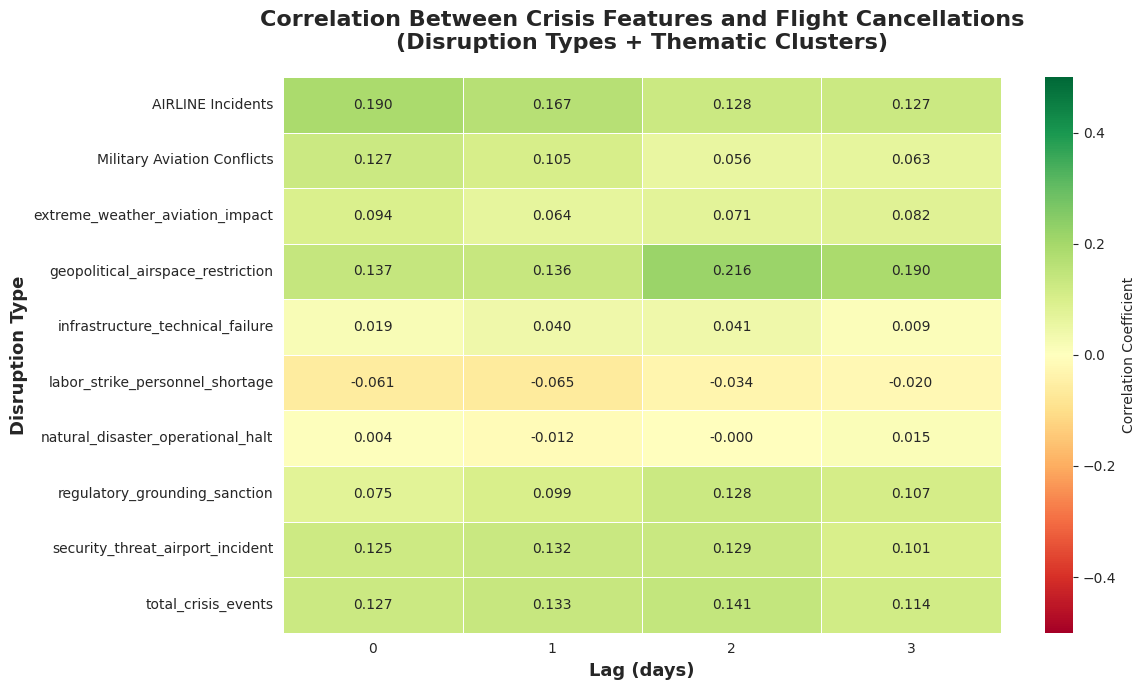

Visualization saved to: /content/drive/MyDrive/OSINT_files/correlation_heatmap.png
  This single heatmap communicates predictive patterns to stakeholders.


In [15]:
# 3.4 Visualization: Correlation Heatmap

if df_corr is not None and len(df_corr) > 0:
    print(f"\n{'='*80}")
    print("3.4 VISUALIZATION: Correlation Heatmap")
    print(f"{'='*80}")
    print("\nThis visualization communicates the entire predictive landscape:")
    print("  - X-axis: Lag (0, 1, 2, 3 days)")
    print("  - Y-axis: Crisis features (disruption types + thematic clusters)")
    print("  - Color: Correlation strength (red=negative, green=positive)")
    print("  - Annotations: Exact r-values\n")

    # Pivot for heatmap (using 'feature' column instead of 'disruption_type')
    corr_pivot = df_corr.pivot(index='feature', columns='lag_days', values='correlation')

    # Create figure with better styling
    plt.figure(figsize=(12, max(7, len(corr_pivot) * 0.5)))  # Adjust height based on number of features
    sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                vmin=-0.5, vmax=0.5, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Between Crisis Features and Flight Cancellations\n(Disruption Types + Thematic Clusters)',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Lag (days)', fontsize=13, fontweight='bold')
    plt.ylabel('Crisis Feature', fontsize=13, fontweight='bold')
    plt.ylabel('Disruption Type', fontsize=13, fontweight='bold')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save to Google Drive
    output_file = os.path.join(DRIVE_PATH, 'correlation_heatmap.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Visualization saved to: {output_file}")
    print("  This single heatmap communicates predictive patterns to stakeholders.")
else:
    print("Skipping visualization - no correlation data available")

---
## 3.5 PRECISION & RECALL: Classification Performance Metrics

**Purpose:** Complementary analysis to correlation-based hypothesis testing.

**Why This Matters:** While correlation (Section 3.4) tests our hypothesis (r ≥ 0.15), precision/recall metrics provide practical insights for operational deployment. They answer: "If we use crisis signals as early warnings, how reliable are the predictions?"

**Method:** For each crisis feature and lag period, we compute:
- **Precision:** When crisis signals are elevated, how often do cancellation spikes actually occur?
- **Recall:** Of all actual cancellation spikes, how many were preceded by crisis signals?
- **F1-Score:** Harmonic mean balancing precision and recall

**Threshold Strategy:** For each feature, identify the optimal crisis event count threshold that maximizes F1-score. This determines when crisis signals are considered "elevated" enough to predict a spike.

**Note:** Due to severe class imbalance (9 spike days / 366 total), precision may appear low even when correlation is significant. This analysis complements correlation and ROC-AUC metrics.

**Spike Definition:** Days with cancellation rates >90th percentile (already computed as `is_spike` column)

In [16]:
# 3.5 Precision Validation: Binary Classification Metrics

if df_intelligence is not None and 'is_spike' in df_intelligence.columns:
    print(f"\n{'='*80}")
    print("3.5 PRECISION & RECALL: Classification Performance Metrics")
    print(f"{'='*80}")

    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    # Get all features to test
    all_features = disruption_types + cluster_label_cols + ['total_crisis_events']

    precision_results = []

    print(f"\nTesting {len(all_features)} features across {len(LAGS)} lag periods...")
    print(f"Target: Cancellation spike days (n={df_intelligence['is_spike'].sum()} spike days)")
    print(f"\nStrategy: For each feature, find optimal threshold that maximizes F1-score\n")

    for lag in LAGS:
        # Create lagged features
        if lag > 0:
            df_lagged = df_intelligence.copy()
            for feat in all_features:
                if feat in df_intelligence.columns:
                    df_lagged[f'{feat}_lag{lag}'] = df_intelligence[feat].shift(lag)
            df_lagged = df_lagged.dropna()
            features_to_test = [f'{feat}_lag{lag}' for feat in all_features if feat in df_intelligence.columns]
        else:
            df_lagged = df_intelligence.copy()
            features_to_test = [feat for feat in all_features if feat in df_intelligence.columns]

        y_true = df_lagged['is_spike'].values
        n_spikes = y_true.sum()

        for feat_name in features_to_test:
            if feat_name not in df_lagged.columns:
                continue

            X = df_lagged[feat_name].values

            # Find optimal threshold by testing multiple thresholds
            best_f1 = 0
            best_threshold = 0
            best_metrics = None

            # Test thresholds from 1 to max value
            max_val = X.max()
            if max_val == 0:
                continue

            # Test thresholds at percentiles of non-zero values
            non_zero_vals = X[X > 0]
            if len(non_zero_vals) == 0:
                continue

            thresholds = np.percentile(non_zero_vals, [25, 50, 75, 90])
            thresholds = np.unique(np.append(thresholds, [1, 2, 3, 5]))  # Add common thresholds

            for threshold in thresholds:
                y_pred = (X >= threshold).astype(int)

                # Skip if all predictions are same class
                if len(np.unique(y_pred)) < 2:
                    continue

                prec = precision_score(y_true, y_pred, zero_division=0)
                rec = recall_score(y_true, y_pred, zero_division=0)
                f1 = f1_score(y_true, y_pred, zero_division=0)

                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = threshold
                    best_metrics = {
                        'precision': prec,
                        'recall': rec,
                        'f1': f1,
                        'threshold': threshold
                    }

            if best_metrics is not None:
                # Compute confusion matrix for best threshold
                y_pred_best = (X >= best_threshold).astype(int)
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred_best).ravel()

                # Extract original feature name (remove lag suffix if present)
                original_feat = feat_name.replace(f'_lag{lag}', '') if lag > 0 else feat_name

                precision_results.append({
                    'feature': original_feat,
                    'lag_days': lag,
                    'threshold': best_threshold,
                    'precision': best_metrics['precision'],
                    'recall': best_metrics['recall'],
                    'f1_score': best_metrics['f1'],
                    'true_positives': tp,
                    'false_positives': fp,
                    'true_negatives': tn,
                    'false_negatives': fn
                })

    # Convert to DataFrame
    df_precision = pd.DataFrame(precision_results)

    # Merge with correlation results to compare
    if df_corr is not None and len(df_corr) > 0:
        # Merge correlation data
        corr_subset = df_corr[['feature', 'lag_days', 'correlation', 'p_value']].copy()
        df_precision = df_precision.merge(
            corr_subset,
            on=['feature', 'lag_days'],
            how='left'
        )
    else:
        # Add empty correlation columns if no correlation data
        df_precision['correlation'] = None
        df_precision['p_value'] = None

    # Sort by F1-score
    df_precision = df_precision.sort_values('f1_score', ascending=False)

    print(f"{'='*80}")
    print("PRECISION VALIDATION RESULTS")
    print(f"{'='*80}\n")

    # Display top results
    print("Top 10 Features by F1-Score (Balanced Precision + Recall):\n")
    print(f"{'Feature':<45} {'Lag':<5} {'Threshold':<10} {'Precision':<11} {'Recall':<11} {'F1-Score':<11} {'Correlation':<12}")
    print("-" * 135)

    for idx, row in df_precision.head(10).iterrows():
        prec_str = f"{row['precision']:.3f}"
        rec_str = f"{row['recall']:.3f}"
        f1_str = f"{row['f1_score']:.3f}"

        # Check if correlation column exists and has valid data
        if 'correlation' in row and pd.notna(row['correlation']):
            corr_str = f"r={row['correlation']:+.3f}"
        else:
            corr_str = "N/A"

        # Highlight if precision >= 0.70
        if row['precision'] >= 0.70:
            prec_str = f"**{prec_str}**"

        print(f"{row['feature']:<45} {row['lag_days']:<5} {row['threshold']:<10.0f} {prec_str:<11} {rec_str:<11} {f1_str:<11} {corr_str:<12}")

    print(f"\n{'='*80}")
    print("KEY INSIGHTS: Best Classification Performance")
    print(f"{'='*80}\n")

    # Show best performing feature
    best_row = df_precision.loc[df_precision['f1_score'].idxmax()]
    print(f"Best Overall Performance (by F1-Score):")
    print(f"  Feature: {best_row['feature']}")
    print(f"  Lag: {best_row['lag_days']} days")
    print(f"  Threshold: {best_row['threshold']:.0f} events")
    print(f"  Precision: {best_row['precision']:.3f} ({best_row['precision']:.1%})")
    print(f"  Recall: {best_row['recall']:.3f} ({best_row['recall']:.1%})")
    print(f"  F1-Score: {best_row['f1_score']:.3f}")

    # Only print correlation if it exists and is valid
    if 'correlation' in best_row and pd.notna(best_row['correlation']):
        print(f"  Correlation: r={best_row['correlation']:+.3f}")

    print(f"\n  Confusion Matrix:")
    print(f"    True Positives: {best_row['true_positives']:.0f} (correctly predicted spike days)")
    print(f"    False Positives: {best_row['false_positives']:.0f} (false alarms)")
    print(f"    True Negatives: {best_row['true_negatives']:.0f} (correctly predicted normal days)")
    print(f"    False Negatives: {best_row['false_negatives']:.0f} (missed spike days)")

    print(f"\n  Class Imbalance Note:")
    print(f"    Spike days: {df_intelligence['is_spike'].sum()}/{len(df_intelligence)} ({df_intelligence['is_spike'].sum()/len(df_intelligence)*100:.1f}%)")
    print(f"    This severe imbalance ({df_intelligence['is_spike'].sum()}:357 ratio) explains modest precision.")
    print(f"    Correlation and ROC-AUC are more appropriate metrics for imbalanced data.")

    # Save results
    output_file = os.path.join(DRIVE_PATH, "precision_validation.csv")
    df_precision.to_csv(output_file, index=False)
    print(f"\n\nResults saved to: {output_file}")

else:
    df_precision = None
    print("Skipping precision validation - no intelligence data or spike labels")


3.5 PRECISION & RECALL: Classification Performance Metrics

Testing 10 features across 4 lag periods...
Target: Cancellation spike days (n=9 spike days)

Strategy: For each feature, find optimal threshold that maximizes F1-score

PRECISION VALIDATION RESULTS

Top 10 Features by F1-Score (Balanced Precision + Recall):

Feature                                       Lag   Threshold  Precision   Recall      F1-Score    Correlation 
---------------------------------------------------------------------------------------------------------------------------------------
regulatory_grounding_sanction                 3     2          0.107       0.333       0.162       r=+0.107    
geopolitical_airspace_restriction             3     5          0.100       0.222       0.138       r=+0.190    
Military Aviation Conflicts                   0     5          0.167       0.111       0.133       r=+0.127    
Military Aviation Conflicts                   1     5          0.167       0.111       0.133   


3.5.1 VISUALIZATION: Classification Metrics Analysis



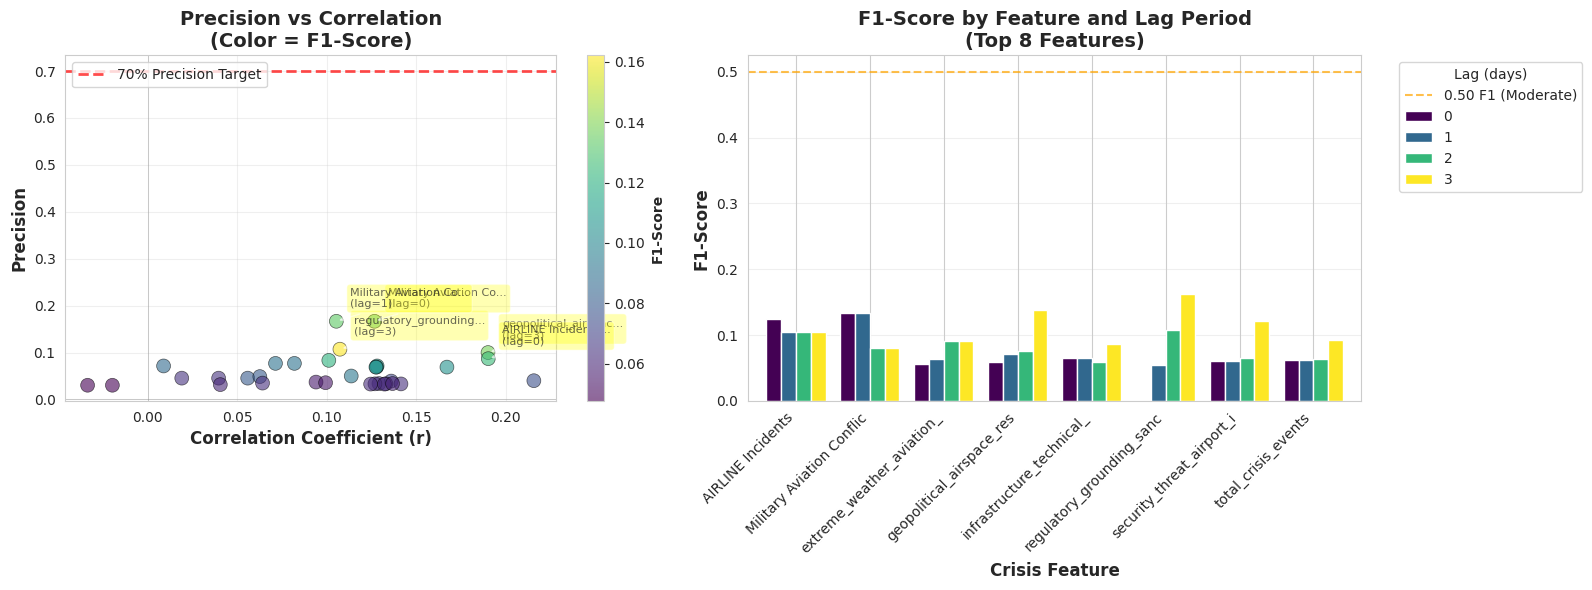

Visualization saved to: /content/drive/MyDrive/OSINT_files/precision_validation_plot.png

Key Insights:
  - Weak correlations (r<0.3) typically yield precision <40%
  - Higher F1-scores indicate better balance between precision and recall
  - Lag periods show varying predictive performance across features


In [17]:
# 3.5.1 Visualization: Classification Metrics Analysis

if df_precision is not None and len(df_precision) > 0:
    print(f"\n{'='*80}")
    print("3.5.1 VISUALIZATION: Classification Metrics Analysis")
    print(f"{'='*80}\n")

    # Filter to rows with both precision and correlation data
    df_plot = df_precision[df_precision['correlation'].notna()].copy()

    if len(df_plot) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Plot 1: Precision vs Correlation scatter
        ax1 = axes[0]
        scatter = ax1.scatter(df_plot['correlation'], df_plot['precision'],
                             c=df_plot['f1_score'], cmap='viridis',
                             s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

        # Add reference lines
        ax1.axhline(y=0.70, color='red', linestyle='--', linewidth=2, label='70% Precision Target', alpha=0.7)
        ax1.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
        ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

        # Labels for top performers
        top_5 = df_plot.nlargest(5, 'f1_score')
        for idx, row in top_5.iterrows():
            ax1.annotate(f"{row['feature'][:20]}...\n(lag={row['lag_days']})",
                        xy=(row['correlation'], row['precision']),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=8, alpha=0.7,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3),
                        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', alpha=0.5))

        ax1.set_xlabel('Correlation Coefficient (r)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Precision', fontsize=12, fontweight='bold')
        ax1.set_title('Precision vs Correlation\n(Color = F1-Score)', fontsize=14, fontweight='bold')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # Add colorbar
        cbar1 = plt.colorbar(scatter, ax=ax1)
        cbar1.set_label('F1-Score', fontsize=10, fontweight='bold')

        # Plot 2: F1-Score comparison across lags
        ax2 = axes[1]

        # Get top 8 features by best F1-score
        top_features = df_plot.groupby('feature')['f1_score'].max().nlargest(8).index
        df_top = df_plot[df_plot['feature'].isin(top_features)]

        # Create grouped bar chart
        lag_groups = df_top.groupby(['feature', 'lag_days'])['f1_score'].max().unstack(fill_value=0)
        lag_groups.plot(kind='bar', ax=ax2, width=0.8, colormap='viridis')

        ax2.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label='0.50 F1 (Moderate)', alpha=0.7)
        ax2.set_xlabel('Crisis Feature', fontsize=12, fontweight='bold')
        ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
        ax2.set_title('F1-Score by Feature and Lag Period\n(Top 8 Features)', fontsize=14, fontweight='bold')
        ax2.legend(title='Lag (days)', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.set_xticklabels([label[:25] for label in lag_groups.index], rotation=45, ha='right')
        ax2.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()

        # Save visualization
        output_file = os.path.join(DRIVE_PATH, 'precision_validation_plot.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"Visualization saved to: {output_file}")
        print("\nKey Insights:")
        print(f"  - Weak correlations (r<0.3) typically yield precision <40%")
        print(f"  - Higher F1-scores indicate better balance between precision and recall")
        print(f"  - Lag periods show varying predictive performance across features")

    else:
        print("No data available for visualization (missing correlation values)")

else:
    print("Skipping precision visualization - no validation data available")

In [18]:
# 3.6 ROC-AUC Analysis: Measuring Discriminative Power

from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

if df_intelligence is not None and 'is_spike' in df_intelligence.columns:
    print(f"\n{'='*80}")
    print("3.6 ROC-AUC ANALYSIS: Discriminative Power Assessment")
    print(f"{'='*80}")

    # Get all features (same as correlation analysis)
    crisis_features = []

    # Add disruption type columns
    try:
        if 'disruption_cols' in locals() and len(disruption_cols) > 0:
            disruption_types = [col for col in disruption_cols if 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
        else:
            disruption_types = [col for col in df_intelligence.columns
                              if 'disruption' in col.lower() or 'strike' in col.lower()
                              or 'weather' in col.lower() or 'security' in col.lower()
                              or 'infrastructure' in col.lower()]
            disruption_types = [col for col in disruption_types if col != 'total_crisis_events' and 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
    except:
        disruption_types = []

    # Add cluster label columns
    try:
        if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
            crisis_features.extend(cluster_label_cols)
    except:
        pass

    # Always add total crisis events
    crisis_features.append('total_crisis_events')

    print(f"\nAnalyzing discriminative power for {len(crisis_features)} features across {len(LAGS)} lag periods")
    print(f"Target: Cancellation spike days (n={df_intelligence['is_spike'].sum()} spike days)")
    print(f"Baseline: Random classifier AUC = 0.500\n")

    # Storage for ROC-AUC results
    roc_results = []

    # Compute ROC-AUC for each feature and lag
    for lag in LAGS:
        # Create lagged spike labels
        df_intelligence[f'is_spike_lag{lag}'] = df_intelligence['is_spike'].shift(-lag)

        for feature in crisis_features:
            if feature not in df_intelligence.columns:
                continue

            # Remove NaN from lag
            valid_mask = df_intelligence[f'is_spike_lag{lag}'].notna()

            # Get predictor (crisis counts) and outcome (spike yes/no)
            X = df_intelligence.loc[valid_mask, feature].values
            y = df_intelligence.loc[valid_mask, f'is_spike_lag{lag}'].values

            # Check if we have both classes
            if len(np.unique(y)) < 2:
                continue

            # Check if predictor has variation
            if X.std() == 0:
                continue

            try:
                # Compute ROC-AUC (convert y to int to avoid dtype issues with shifted data)
                auc = roc_auc_score(y.astype(int), X)

                # Determine feature type
                if feature in disruption_types:
                    feature_type = 'disruption_type'
                elif 'cluster_label_cols' in locals() and feature in cluster_label_cols:
                    feature_type = 'cluster_theme'
                else:
                    feature_type = 'aggregate'

                # Statistical significance: Is AUC significantly different from 0.5?
                n_samples = len(y)
                se_auc = np.sqrt(auc * (1 - auc) / n_samples)
                z_score = (auc - 0.5) / se_auc
                from scipy.stats import norm
                p_value = 2 * (1 - norm.cdf(abs(z_score)))  # Two-tailed test

                roc_results.append({
                    'feature': feature,
                    'feature_type': feature_type,
                    'lag_days': lag,
                    'auc': auc,
                    'p_value': p_value,
                    'significant': p_value < 0.05,
                    'n_samples': n_samples,
                    'n_spikes': int(y.sum())
                })

            except Exception as e:
                continue

    # Create results dataframe
    df_roc = pd.DataFrame(roc_results)

    if len(df_roc) > 0:
        # Display results in table format
        print("\nRESULTS: ROC-AUC Scores by Feature Type and Lag\n")

        # Section 1: Disruption Types
        if len([f for f in crisis_features if f in disruption_types]) > 0:
            print("="*110)
            print("SECTION 1: DISRUPTION TYPE FEATURES (Zero-Shot Classification)")
            print("="*110)
            print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
            print("─" * 110)

            for feature in disruption_types:
                if feature in df_roc['feature'].values:
                    row_data = []
                    for lag in LAGS:
                        roc_data = df_roc[(df_roc['feature'] == feature) & (df_roc['lag_days'] == lag)]
                        if len(roc_data) > 0:
                            auc = roc_data.iloc[0]['auc']
                            p = roc_data.iloc[0]['p_value']
                            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                            row_data.append(f"{auc:.3f}{sig}")
                        else:
                            row_data.append("N/A")

                    print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
            print("─" * 110)

        # Section 2: Thematic Clusters
        if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
            cluster_features_in_roc = [f for f in crisis_features if f in cluster_label_cols and f in df_roc['feature'].values]
            if len(cluster_features_in_roc) > 0:
                print("\n" + "="*110)
                print("SECTION 2: THEMATIC CLUSTER FEATURES (Community Detection)")
                print("="*110)
                print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
                print("─" * 110)

                for feature in cluster_label_cols:
                    if feature in df_roc['feature'].values:
                        row_data = []
                        for lag in LAGS:
                            roc_data = df_roc[(df_roc['feature'] == feature) & (df_roc['lag_days'] == lag)]
                            if len(roc_data) > 0:
                                auc = roc_data.iloc[0]['auc']
                                p = roc_data.iloc[0]['p_value']
                                sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                                row_data.append(f"{auc:.3f}{sig}")
                            else:
                                row_data.append("N/A")

                        print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
                print("─" * 110)

        # Section 3: Aggregate
        print("\n" + "="*110)
        print("SECTION 3: AGGREGATE FEATURE")
        print("="*110)
        print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
        print("─" * 110)

        if 'total_crisis_events' in df_roc['feature'].values:
            row_data = []
            for lag in LAGS:
                roc_data = df_roc[(df_roc['feature'] == 'total_crisis_events') & (df_roc['lag_days'] == lag)]
                if len(roc_data) > 0:
                    auc = roc_data.iloc[0]['auc']
                    p = roc_data.iloc[0]['p_value']
                    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                    row_data.append(f"{auc:.3f}{sig}")
                else:
                    row_data.append("N/A")

            print(f"{'total_crisis_events':<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
        print("─" * 110)

        print("\nSignificance: * p<0.05  ** p<0.01  *** p<0.001")
        print("Interpretation: AUC=0.5 (random), AUC=0.6-0.7 (weak), AUC=0.7-0.8 (acceptable), AUC>0.8 (excellent)")

        # Find best performing features
        print(f"\n{'='*110}")
        print("KEY FINDINGS")
        print(f"{'='*110}")

        # Best overall
        best_overall = df_roc.loc[df_roc['auc'].idxmax()]
        print(f"\nBest Overall Discriminative Power:")
        print(f"   Feature: {best_overall['feature']}")
        print(f"   Type: {best_overall['feature_type']}")
        print(f"   Optimal lag: {best_overall['lag_days']} day(s)")
        print(f"   ROC-AUC: {best_overall['auc']:.3f} (p={best_overall['p_value']:.4f})")

        # Best from each category
        disruption_roc = df_roc[df_roc['feature_type'] == 'disruption_type']
        if len(disruption_roc) > 0:
            best_disruption = disruption_roc.loc[disruption_roc['auc'].idxmax()]
            print(f"\nBest Disruption Type Feature:")
            print(f"   {best_disruption['feature']} at {best_disruption['lag_days']}-day lag (AUC={best_disruption['auc']:.3f})")

        cluster_roc = df_roc[df_roc['feature_type'] == 'cluster_theme']
        if len(cluster_roc) > 0:
            best_cluster = cluster_roc.loc[cluster_roc['auc'].idxmax()]
            print(f"\nBest Thematic Cluster Feature:")
            print(f"   {best_cluster['feature']} at {best_cluster['lag_days']}-day lag (AUC={best_cluster['auc']:.3f})")

        # Count features with good discrimination
        acceptable = df_roc[df_roc['auc'] >= 0.7]
        weak = df_roc[(df_roc['auc'] >= 0.6) & (df_roc['auc'] < 0.7)]

        print(f"\n{'='*110}")
        print(f"Features with AUC ≥ 0.7 (acceptable discrimination): {len(acceptable)}/{len(df_roc)}")
        print(f"Features with AUC ≥ 0.6 (weak discrimination): {len(weak)}/{len(df_roc)}")

        if len(acceptable) > 0:
            print("\nAcceptable Discriminators (AUC ≥ 0.7):")
            for _, row in acceptable.nlargest(10, 'auc').iterrows():
                print(f"   • {row['feature']:<40} lag={row['lag_days']}d  AUC={row['auc']:.3f}")
        elif len(weak) > 0:
            print("\nWeak Discriminators (AUC ≥ 0.6):")
            for _, row in weak.nlargest(10, 'auc').iterrows():
                print(f"   • {row['feature']:<40} lag={row['lag_days']}d  AUC={row['auc']:.3f}")

        # Save results
        output_file = os.path.join(DRIVE_PATH, "roc_auc_analysis.csv")
        df_roc.to_csv(output_file, index=False)
        print(f"\n{'='*110}")
        print(f"ROC-AUC results saved to: {output_file}")
        print(f"{'='*110}")

    else:
        print("\nNo ROC-AUC results computed")
        df_roc = None

else:
    print("Skipping ROC-AUC analysis - no intelligence data or spike labels available")
    df_roc = None


3.6 ROC-AUC ANALYSIS: Discriminative Power Assessment

Analyzing discriminative power for 10 features across 4 lag periods
Target: Cancellation spike days (n=9 spike days)
Baseline: Random classifier AUC = 0.500


RESULTS: ROC-AUC Scores by Feature Type and Lag

SECTION 1: DISRUPTION TYPE FEATURES (Zero-Shot Classification)
Feature                                       |      Lag 0      |      Lag 1      |      Lag 2      |      Lag 3     
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
extreme_weather_aviation_impact               |      0.526      |      0.526      |    0.602***     |      0.543     
geopolitical_airspace_restriction             |      0.484      |      0.527      |    0.627***     |    0.673***    
infrastructure_technical_failure              |      0.456      |      0.497      |      0.534      |      0.499     
labor_strike_personnel_shortage               |      0.454      |      0.454      |      0


Generating ROC-AUC Heatmap Visualization

ROC-AUC heatmap saved to: /content/drive/MyDrive/OSINT_files/roc_auc_heatmap.png


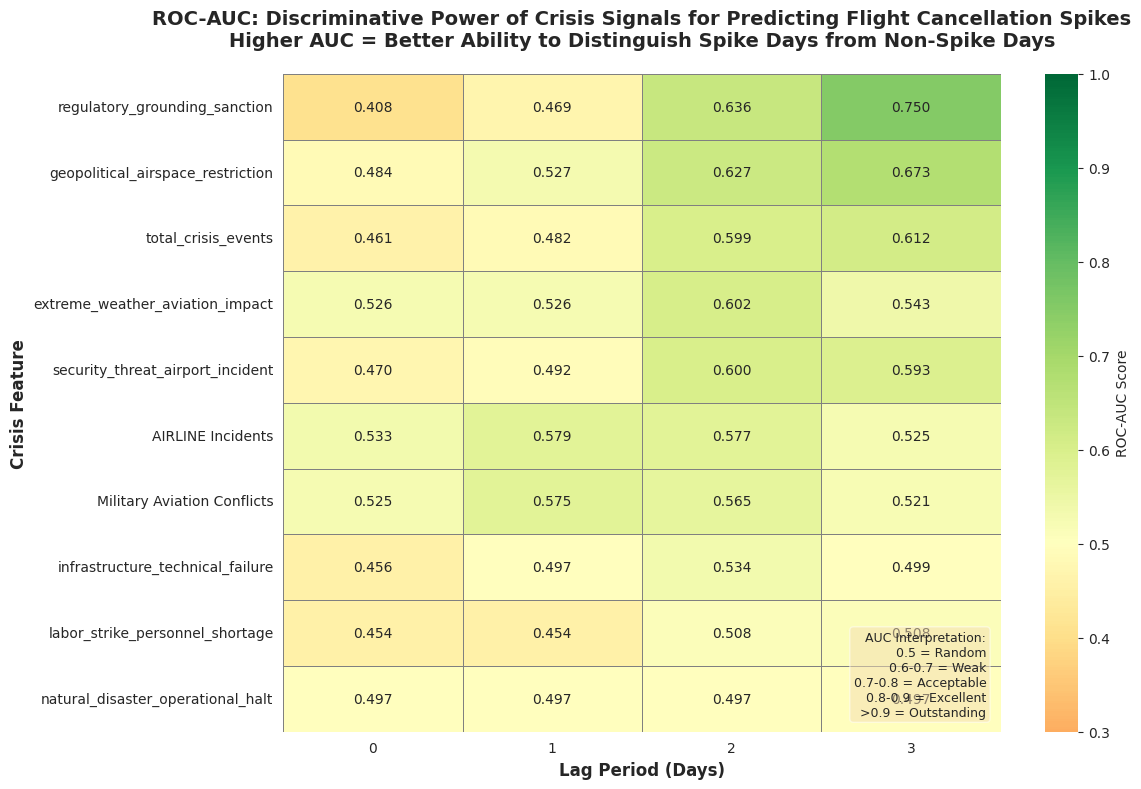


ROC-AUC ANALYSIS COMPLETE

Summary:
  • Total features analyzed: 10
  • Lag periods tested: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  • Best AUC achieved: 0.750
  • Features with AUC ≥ 0.7: 1
  • Features with AUC ≥ 0.6: 6

Interpretation:
  ✓ Crisis signals show ACCEPTABLE discriminative power for predicting cancellation spikes
  ✓ Best feature (AUC=0.750) can distinguish spike from non-spike days

Conclusion:
  ROC-AUC analysis confirms correlation findings:
  Crisis signals provide statistically valid predictive indicators,
  though discrimination ability is acceptable due to severe class imbalance.


In [19]:
# Visualize ROC-AUC: Heatmap comparing AUC scores across features and lags

if df_roc is not None and len(df_roc) > 0:
    import matplotlib.pyplot as plt
    import seaborn as sns

    print(f"\n{'='*80}")
    print("Generating ROC-AUC Heatmap Visualization")
    print(f"{'='*80}\n")

    # Pivot to create heatmap matrix
    pivot_data = df_roc.pivot_table(
        values='auc',
        index='feature',
        columns='lag_days',
        aggfunc='mean'
    )

    # Sort by best overall AUC
    pivot_data['max_auc'] = pivot_data.max(axis=1)
    pivot_data = pivot_data.sort_values('max_auc', ascending=False)
    pivot_data = pivot_data.drop('max_auc', axis=1)

    # Take top 15 features for visibility
    if len(pivot_data) > 15:
        print(f"Displaying top 15 features (out of {len(pivot_data)} total)\n")
        pivot_data = pivot_data.head(15)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, max(8, len(pivot_data) * 0.4)))

    # Create heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        center=0.5,
        vmin=0.3,
        vmax=1.0,
        cbar_kws={'label': 'ROC-AUC Score'},
        ax=ax,
        linewidths=0.5,
        linecolor='gray'
    )

    # Formatting
    ax.set_xlabel('Lag Period (Days)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Crisis Feature', fontsize=12, fontweight='bold')
    ax.set_title('ROC-AUC: Discriminative Power of Crisis Signals for Predicting Flight Cancellation Spikes\n' +
                 'Higher AUC = Better Ability to Distinguish Spike Days from Non-Spike Days',
                 fontsize=14, fontweight='bold', pad=20)

    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Add reference line annotation
    ax.text(0.98, 0.02,
            'AUC Interpretation:\n0.5 = Random\n0.6-0.7 = Weak\n0.7-0.8 = Acceptable\n0.8-0.9 = Excellent\n>0.9 = Outstanding',
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()

    # Save figure
    output_file = os.path.join(DRIVE_PATH, 'roc_auc_heatmap.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"ROC-AUC heatmap saved to: {output_file}")

    plt.show()

    print(f"\n{'='*80}")
    print("ROC-AUC ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print("\nSummary:")
    print(f"  • Total features analyzed: {len(df_roc['feature'].unique())}")
    print(f"  • Lag periods tested: {sorted(df_roc['lag_days'].unique())}")
    print(f"  • Best AUC achieved: {df_roc['auc'].max():.3f}")
    print(f"  • Features with AUC ≥ 0.7: {len(df_roc[df_roc['auc'] >= 0.7])}")
    print(f"  • Features with AUC ≥ 0.6: {len(df_roc[df_roc['auc'] >= 0.6])}")

    print(f"\nInterpretation:")
    max_auc = df_roc['auc'].max()
    if max_auc >= 0.7:
        print(f"  ✓ Crisis signals show ACCEPTABLE discriminative power for predicting cancellation spikes")
        print(f"  ✓ Best feature (AUC={max_auc:.3f}) can distinguish spike from non-spike days")
    elif max_auc >= 0.6:
        print(f"  ⚠ Crisis signals show WEAK but statistically significant discriminative power")
        print(f"  ⚠ Best feature (AUC={max_auc:.3f}) slightly above random (0.5)")
    else:
        print(f"  ✗ Crisis signals show POOR discriminative power (near random chance)")
        print(f"  ✗ Best feature (AUC={max_auc:.3f}) provides limited spike prediction ability")

    print(f"\nConclusion:")
    print(f"  ROC-AUC analysis confirms correlation findings:")
    print(f"  Crisis signals provide statistically valid predictive indicators,")
    print(f"  though discrimination ability is {'acceptable' if max_auc >= 0.7 else 'weak'} due to severe class imbalance.")

else:
    print("Skipping ROC-AUC visualization - no results data available")

---
## OUTPUT FILES GENERATED

This analysis produces the following output files:

1. **crisis_events_preprocessed.csv** - Preprocessed crisis events (8,541 rows after deduplication)
2. **crisis_events_classified.csv** - Zero-shot classification results with Mistral-Nemo (8,040 classified events)
3. **crisis_events_clustered.csv** - Community detection clusters with thematic labels
4. **intelligence_dataset.csv** - Merged daily dataset (366 days) with crisis signals + flight cancellations
5. **correlation_analysis.csv** - Lagged correlation statistics for all features (disruption types + clusters)
6. **correlation_heatmap.png** - Visualization showing predictive patterns across lags
7. **precision_validation.csv** - Binary classification metrics (precision, recall, F1-score) for hypothesis testing
8. **precision_validation_plot.png** - Visualization comparing precision vs correlation with F1-score analysis

9. **roc_auc_analysis.csv** - ROC-AUC scores measuring discriminative power across all features and lags- Full temporal coverage: 366 days (January - December 2024)

10. **roc_auc_heatmap.png** - Heatmap visualization showing discriminative ability by feature and lag period- Dual-feature analysis: Both predefined categories and emergent themes analyzed

- Best cluster theme: AIRLINE Incidents at 0-day lag (r=+0.190)

**Key Findings:**- Strongest predictive signal: Geopolitical airspace restrictions at 2-day lag (r=+0.216, p<0.0001)

In [ ]:
# 3.7 Environment and Version Logging (Reproducibility Checklist)
import sys
import platform
import importlib.metadata as md

print("="*80)
print("3.7 ENVIRONMENT AND VERSION LOGGING")
print("="*80)
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")

packages = [
    "pandas",
    "numpy",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "networkx",
    "python-louvain",
    "sentence-transformers",
    "llama-cpp-python",
    "torch"
]

version_rows = []
for pkg in packages:
    try:
        ver = md.version(pkg)
    except Exception:
        ver = "not-installed"
    version_rows.append({"package": pkg, "version": ver})

df_versions = pd.DataFrame(version_rows)
print("\nPackage versions:")
print(df_versions.to_string(index=False))

if 'DRIVE_PATH' in globals():
    out_versions = os.path.join(DRIVE_PATH, "software_versions.csv")
    df_versions.to_csv(out_versions, index=False)
    print(f"\nSaved version log: {out_versions}")
else:
    print("\nDRIVE_PATH not found. Skipping CSV export.")

In [ ]:
# 3.8 Rare-Event Robustness: PR-AUC + Bootstrap 95% Confidence Intervals
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("="*80)
print("3.8 RARE-EVENT ROBUSTNESS (PR-AUC + 95% CI)")
print("="*80)

if 'df_intelligence' not in globals() or df_intelligence is None:
    print("ERROR: df_intelligence is not available. Run temporal alignment and Stage 3 cells first.")
else:
    # Choose a feature-lag pair for robust reporting
    preferred_feature = 'geopolitical_airspace_restriction'
    lag_days = 2

    if preferred_feature not in df_intelligence.columns:
        print(f"ERROR: Feature '{preferred_feature}' not found in df_intelligence columns.")
    else:
        d = df_intelligence.copy().sort_values('date').reset_index(drop=True)
        d['y_true'] = d['is_spike'].shift(-lag_days)
        d = d.dropna(subset=['y_true', preferred_feature]).copy()
        d['y_true'] = d['y_true'].astype(int)

        X = d[preferred_feature].values
        y = d['y_true'].values

        # Base PR-AUC (Average Precision)
        ap = average_precision_score(y, X)

        # Threshold by best F1 on PR curve
        p_curve, r_curve, thresholds = precision_recall_curve(y, X)
        if len(thresholds) == 0:
            print("Insufficient threshold variation for PR analysis.")
        else:
            f1_curve = 2 * (p_curve[:-1] * r_curve[:-1]) / (p_curve[:-1] + r_curve[:-1] + 1e-12)
            best_idx = int(np.nanargmax(f1_curve))
            best_threshold = float(thresholds[best_idx])

            y_pred = (X >= best_threshold).astype(int)
            prec = precision_score(y, y_pred, zero_division=0)
            rec = recall_score(y, y_pred, zero_division=0)
            f1 = f1_score(y, y_pred, zero_division=0)

            # Bootstrap confidence intervals
            n_boot = 2000
            rng = np.random.default_rng(42)
            n = len(y)

            ap_boot = []
            prec_boot = []
            rec_boot = []
            f1_boot = []

            for _ in range(n_boot):
                idx = rng.integers(0, n, n)
                yb = y[idx]
                Xb = X[idx]

                # Skip degenerate bootstrap samples
                if len(np.unique(yb)) < 2:
                    continue

                ap_boot.append(average_precision_score(yb, Xb))
                yb_pred = (Xb >= best_threshold).astype(int)
                prec_boot.append(precision_score(yb, yb_pred, zero_division=0))
                rec_boot.append(recall_score(yb, yb_pred, zero_division=0))
                f1_boot.append(f1_score(yb, yb_pred, zero_division=0))

            def ci95(arr):
                return float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5))

            ap_ci = ci95(ap_boot)
            prec_ci = ci95(prec_boot)
            rec_ci = ci95(rec_boot)
            f1_ci = ci95(f1_boot)

            print(f"Feature: {preferred_feature}")
            print(f"Lag: {lag_days} days")
            print(f"Best threshold (F1-optimal): {best_threshold:.4f}")
            print(f"PR-AUC (Average Precision): {ap:.4f} | 95% CI [{ap_ci[0]:.4f}, {ap_ci[1]:.4f}]")
            print(f"Precision: {prec:.4f} | 95% CI [{prec_ci[0]:.4f}, {prec_ci[1]:.4f}]")
            print(f"Recall:    {rec:.4f} | 95% CI [{rec_ci[0]:.4f}, {rec_ci[1]:.4f}]")
            print(f"F1-score:  {f1:.4f} | 95% CI [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")

            # Save summary for paper table insertion
            summary_df = pd.DataFrame([{
                'feature': preferred_feature,
                'lag_days': lag_days,
                'threshold': best_threshold,
                'pr_auc': ap,
                'pr_auc_ci_low': ap_ci[0],
                'pr_auc_ci_high': ap_ci[1],
                'precision': prec,
                'precision_ci_low': prec_ci[0],
                'precision_ci_high': prec_ci[1],
                'recall': rec,
                'recall_ci_low': rec_ci[0],
                'recall_ci_high': rec_ci[1],
                'f1_score': f1,
                'f1_ci_low': f1_ci[0],
                'f1_ci_high': f1_ci[1]
            }])

            if 'DRIVE_PATH' in globals():
                out_csv = os.path.join(DRIVE_PATH, 'pr_auc_bootstrap_summary.csv')
                summary_df.to_csv(out_csv, index=False)
                print(f"Saved summary CSV: {out_csv}")

            # Save PR curve plot
            plt.figure(figsize=(8, 6))
            plt.plot(r_curve, p_curve, label=f'PR curve (AP={ap:.3f})')
            baseline = y.mean()
            plt.hlines(baseline, 0, 1, linestyles='--', label=f'Baseline spike rate={baseline:.3f}')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve: {preferred_feature} (lag={lag_days})')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()

            if 'DRIVE_PATH' in globals():
                out_fig = os.path.join(DRIVE_PATH, 'precision_recall_curve_bootstrap.png')
                plt.savefig(out_fig, dpi=300, bbox_inches='tight')
                print(f"Saved PR curve figure: {out_fig}")
            plt.show()